## Parte 0

In [1]:
# !pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu126
# !pip install albumentations

In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt
from pathlib import Path
import albumentations as A
import cv2
import time


import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from albumentations.pytorch import ToTensorV2


import matplotlib.colors as mcolors
from scipy.ndimage import label
from skimage.segmentation import watershed
from torchvision.utils import make_grid

In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_d3fdaeaee8be81e14e5601d9a59687c7"

# 1. Baixa o arquivo principal da competição
!kaggle competitions download -c data-science-bowl-2018

# 2. Descompacta o arquivo principal em uma pasta temporária
!unzip -q data-science-bowl-2018.zip -d dataset_temp/

# 3. Descompacta APENAS o stage1_train.zip na pasta final
!unzip -q dataset_temp/stage1_train.zip -d stage1_train/

# 4. Limpa os arquivos pesados para liberar espaço
!rm data-science-bowl-2018.zip
!rm -rf dataset_temp/

100% 358M/358M [00:03<00:00, 104MB/s] 



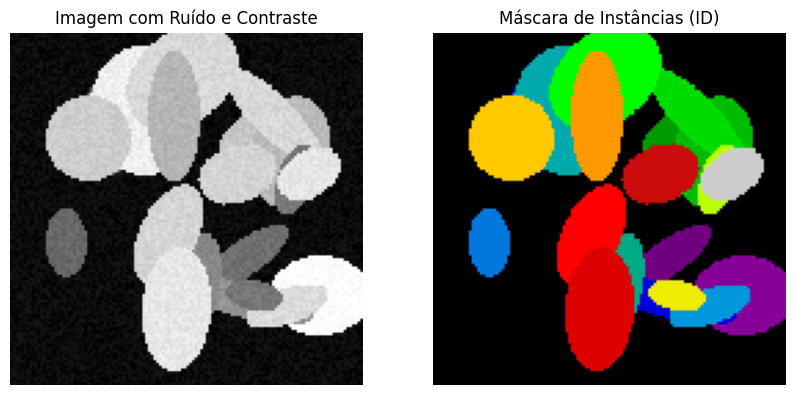

In [4]:
def generateEllipses(img_size):
    # Vamos adicinar um contraste para o fundo da imagem
    bg_intensity = np.random.randint(20,80)
    img = np.full((img_size, img_size), bg_intensity, dtype=np.uint8)

    # Evitar overflow
    mask = np.zeros((img_size, img_size), dtype=np.int32)

    num_ellipses = np.random.randint(15,21)

    # Para cada elipse, define o formato, a posição e a intensidade
    for i in range(1, num_ellipses+1):
        center = (int(np.random.randint(15, img_size-15)), int(np.random.randint(15, img_size-15)))
        axes = (int(np.random.randint(5,25)), int(np.random.randint(5,25)))
        angle = int(np.random.randint(0,180))
        intensity = int(np.random.randint(100,255))

        cv2.ellipse(img, center, axes, angle, 0, 360, intensity, -1)
        cv2.ellipse(mask, center, axes, angle, 0, 360, i, -1)

    std_dev = np.random.uniform(5.0, 30.0)
    noise = np.random.uniform(0, std_dev, (img_size, img_size))

    noisy_img = np.clip(img + noise, 0, 255)

    return noisy_img, mask

img, mask = generateEllipses(128)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Imagem com Ruído e Contraste")
axes[0].axis('off')

axes[1].imshow(mask, cmap='nipy_spectral')
axes[1].set_title("Máscara de Instâncias (ID)")
axes[1].axis('off')
plt.show()

In [5]:
class EllipsesDataset(Dataset):
  def __init__(self, num_samples) -> None:
     self.num_samples = num_samples

  def __len__(self):
    return self.num_samples

  def __getitem__(self, index):
    img, mask = generateEllipses(128)
    tensor_img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
    tensor_mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
    return tensor_img, tensor_mask

ellip_data_train = EllipsesDataset(800)
ellip_loader_train = DataLoader(ellip_data_train, batch_size=16)

ellip_data_val = EllipsesDataset(200)
ellip_loader_val = DataLoader(ellip_data_val, batch_size=16)

In [6]:
def binarize_mask(mask):
    return (mask > 0).float()

In [7]:
def binary_decoder(mask, threshold):
    return (torch.sigmoid(mask) > threshold).float()


def multiclass_decoder(mask, dim):
    return torch.argmax(mask, dim=dim).float()

In [ ]:
# Para treinar com as elipses criadas acima usaremos a U-Net
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(UNet, self).__init__()
        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(128,256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Passa pelo primeiro bloco e salva
        skip1 = self.conv1(x)
        x = self.pool1(skip1)
        skip2 = self.conv2(x)
        x = self.pool2(skip2)


        x = self.bottleneck(x)
        x = self.up1(x)
        x = torch.cat((skip2, x), dim=1)
        x = self.dec1(x)


        x = self.up2(x)
        x = torch.cat((skip1, x), dim=1)
        x = self.dec2(x)

        return self.final_conv(x)

def compute_semantic_metrics(pred, mask):
    pred_bin = (torch.sigmoid(pred) > 0.5).float()
    mask_bin = (mask > 0).float()
    # print(f"Dimensoes do pred e da mask depois do unsqueeze: {pred.shape}, {mask.shape}")
    intersection = torch.sum((pred_bin*mask_bin))
    union = torch.sum((pred_bin+mask_bin)) - intersection
    iou = intersection / (union + 1e-8)
    dice = 2 * intersection / (torch.sum(pred_bin) + torch.sum(mask_bin) + 1e-8)

    return {'iou': iou.item(), 'dice': dice.item()}

def train_loop(model, optimizer, loader_train, transform_mask, loss):
    loss_train = 0.0
    model.train()
    for img, mask in loader_train:
        device = img.device
        img = img.to(device)
        mask = mask.to(device)

        # Aplica uma transformacao na mascara, caso desejado
        if not transform_mask is None:
            mask = transform_mask(mask)

        optimizer.zero_grad()
        pred = model.forward(img)
        loss_value = loss(pred, mask)
        loss_train += loss_value.item()
        loss_value.backward()
        optimizer.step()
    mean_loss_train = loss_train / len(loader_train)
    return mean_loss_train

def val_loop(model, loader_val, transform_mask, loss, decoder, metric_function,**kwargs):
    model.eval()
    loss_val = 0.0
    total_metrics = {}
    img_count = 0
    with torch.no_grad():
        for img, mask_original in loader_val:
            device = img.device
            img = img.to(device)
            mask_original = mask_original.to(device)
            # Aplica uma transformacao na mascara, caso desejado
            if not transform_mask is None:
                mask = transform_mask(mask_original)
            else:
                mask = mask_original

            pred = model.forward(img)
            loss_value = loss(pred, mask)
            loss_val += loss_value.item()
            pred = decoder(pred, **kwargs)
            # print(img.shape)
            for b in range(img.shape[0]):
                # Chama a função de métrica que foi passada como parâmetro
                metrics = metric_function(pred[b], mask_original[b])

                # Acumula as métricas dinamicamente
                for key, val in metrics.items():
                    total_metrics[key] = total_metrics.get(key, 0.0) + val
                img_count += 1
    mean_loss_val = loss_val / len(loader_val)
    mean_metrics = {k: v / img_count for k, v in total_metrics.items()}

    return mean_loss_val, mean_metrics

def train_model(
    model,
    loader_train,
    loader_val,
    optimizer,
    epochs=50,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=None,
    decoder=binary_decoder,
    metric_function = compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    best_model_path='melhor_modelo.pth',
    **kwargs
):

    time_begin = time.time()
    metrics_history = []
    best_metric = -float('inf')
    for epoch in range(epochs):
        mean_loss_train = train_loop(model, optimizer, loader_train, transform_mask, loss)
        mean_loss_val, mean_metrics = val_loop(model, loader_val, transform_mask, loss, decoder, metric_function,**kwargs)
        metrics_history.append((mean_loss_train, mean_loss_val, mean_metrics))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}] | Val Loss: {mean_loss_val:.4f} | Train Loss: {mean_loss_train:.4f}")
            print(" | ".join([f"Val {k.upper()}: {v:.4f}" for k, v in mean_metrics.items()]))

        current_metric = mean_metrics.get(stop_metric, 0.0)

        if current_metric >= stop_threshold:
            print(f"Early stopping")
            break

        if current_metric > best_metric:
            torch.save(model.state_dict(), best_model_path)
            best_metric = current_metric
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping: Sem melhoria por {patience} epocas consecutivas.")
                break

    model.load_state_dict(torch.load(best_model_path))
    time_end = time.time()
    print(f"Train time: {(time_end - time_begin)/60} minutes")

    return metrics_history

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=1, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(
    model,
    loader_train=ellip_loader_train,
    loader_val=ellip_loader_val,
    optimizer=optimizer,
    epochs=50,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=binarize_mask,
    decoder=binary_decoder,
    metric_function=compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    best_model_path="models/best_model_parte_00.pth",
    threshold=0.5
)

Epoch [1/50] | Val Loss: 0.0543 | Train Loss: 0.1164
Val IOU: 0.9928 | Val DICE: 0.9964
Early stopping


RuntimeError: Error(s) in loading state_dict for UNet:
	size mismatch for conv1.conv.0.weight: copying a param with shape torch.Size([64, 3, 3, 3]) from checkpoint, the shape in current model is torch.Size([64, 1, 3, 3]).
	size mismatch for final_conv.weight: copying a param with shape torch.Size([3, 64, 1, 1]) from checkpoint, the shape in current model is torch.Size([1, 64, 1, 1]).
	size mismatch for final_conv.bias: copying a param with shape torch.Size([3]) from checkpoint, the shape in current model is torch.Size([1]).

# Parte 1

In [12]:
class BBBC038Dataset(Dataset):

    def __init__(self, root, transform):
        self.root = Path(root)

        # Encontra todas as imagens
        self.images = sorted(self.root.glob("*/images/*.png"))
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image_path = self.images[idx]

        # Pasta correspondente a imagem
        sample_dir = image_path.parent.parent

        # Carrega a imagem em um tensor
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # (BGR ==> RGB)

        # Carrega as mascaras
        mask_paths = sorted((sample_dir / "masks").glob("*.png"))

        masks = []

        for i in range(len(mask_paths)):
            mask_path = mask_paths[i]
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask != 0) * (i + 1)
            masks.append(mask)

        mask = np.stack(masks).max(0).astype(int)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.unsqueeze(0).float()

        return image, mask

In [14]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

def desnorm(img, mean=MEAN, std=STD):
    img_plot = img.cpu().permute(1, 2, 0).numpy()
    mean = np.array(mean)
    std = np.array(std)
    img_plot = (img_plot * std) + mean
    return np.clip(img_plot, 0, 1)

# Pipeline para redimensionamento das imagens
train_transform = A.Compose([
    # Forca image e mask para 256x256
    A.Resize(height=256, width=256),

    # Padroniza o espectro de cores como cinza
    A.ToGray(p=1.0),

    # Normaliza os pixels para o padrao ImageNet
    A.Normalize(mean=MEAN, std=STD),

    # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
    ToTensorV2()
])

batch_size = 16

dataset = BBBC038Dataset("stage1_train", train_transform)
# dataloader = DataLoader(dataset, batch_size=batch_size)
train_dataset, val_dataset = torch.utils.data.dataset.random_split(dataset, [0.8,0.2])
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

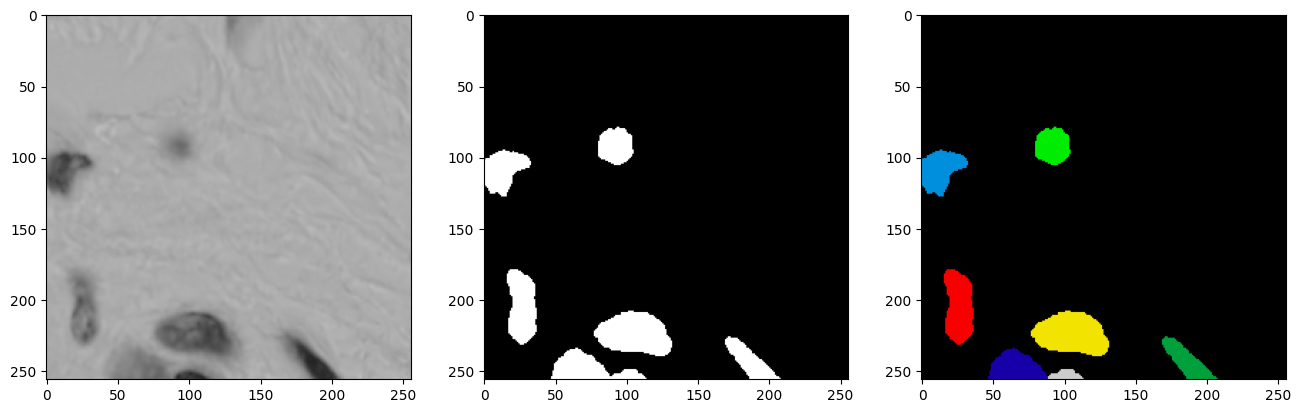

In [15]:
for i, (img, mask) in enumerate(train_dataloader):
    img = img.to(device)
    mask = mask.to(device)

    # Desfaz a normalizacao da imagem
    img_plot = desnorm(img[0])

    fig, axes = plt.subplots(1, 3, figsize=(16, 10))
    mask = mask[0][0].cpu().numpy()
    axes[0].imshow(img_plot)
    axes[1].imshow(mask != 0, cmap='gray')
    axes[2].imshow(mask, cmap='nipy_spectral')
    break

In [ ]:
# Treino do modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_model(
    model,
    loader_train=train_dataloader,
    loader_val=val_dataloader,
    optimizer=optimizer,
    epochs=1,
    loss=nn.BCEWithLogitsLoss(),
    transform_mask=binarize_mask,
    decoder=binary_decoder,
    metric_function=compute_semantic_metrics,
    stop_metric='iou',
    stop_threshold=0.99,
    patience=5,
    best_model_path="models/best_model_parte_01.pth",
    threshold=0.5
)

Epoch [1/1] | Val Loss: 0.2581 | Train Loss: 0.3595
Val IOU: 0.5272 | Val DICE: 0.6470
Train time: 1.1303783893585204 minutes


[(0.3594500917722197,
  0.25808196763197583,
  {'iou': 0.5272226303940944, 'dice': 0.6469649336815103})]

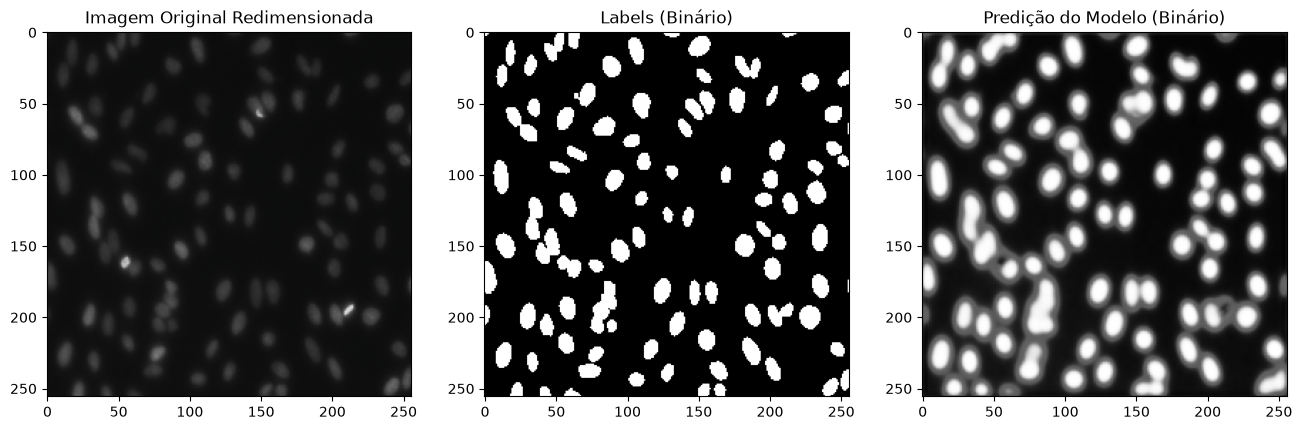

In [ ]:
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
      if i != 0: continue
      img = img.to(device)
      mask = mask.to(device)
      mask = (mask > 0).float()

      # Desfaz a normalizacao da imagem
      img_plot = desnorm(img[0])
      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()

      fig, axes = plt.subplots(1, 3, figsize=(16, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Original Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='gray')
      axes[1].set(
        title="Labels (Binário)"
      )
      axes[2].imshow(pred[0], cmap='gray')
      axes[2].set(
        title="Predição do Modelo (Binário)"
      )
      break

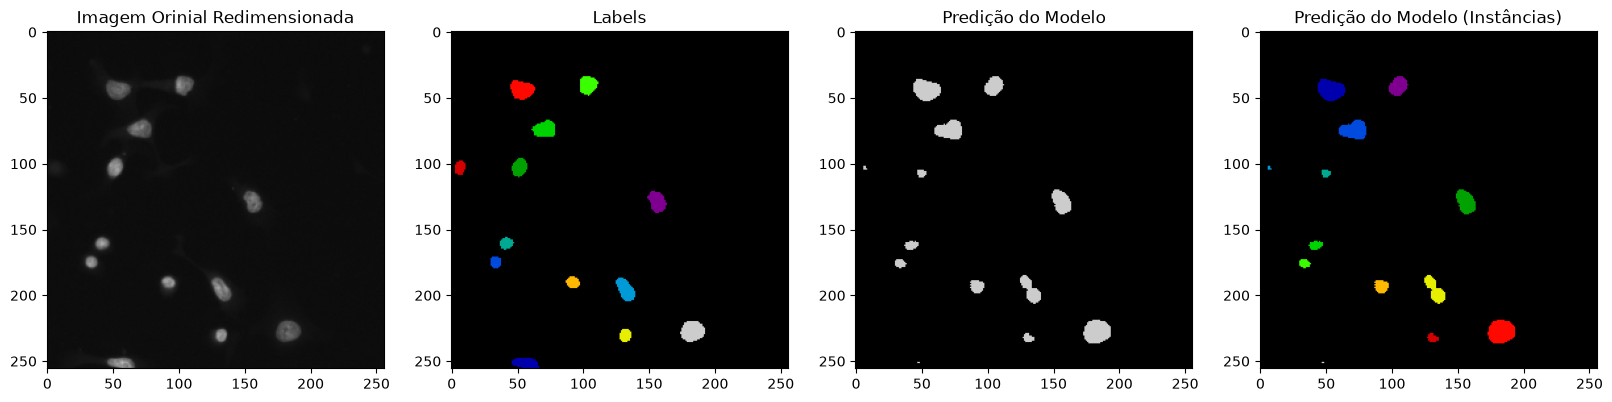

In [ ]:
# Extrair instâncias pelo método ingênuo
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
      img = img.to(device)
      mask = mask.to(device)

      # Desfaz a normalizacao da imagem
      img_plot = desnorm(img[0])

      pred = model(img)
      pred = torch.sigmoid(pred)[0].cpu().numpy()
      # Limiar
      pred_bin = (pred > 0.5).astype(int)
      # Componentes Conexas
      inst_matrix, num_obj = label(pred_bin[0])

      fig, axes = plt.subplots(1, 4, figsize=(20, 10))
      axes[0].imshow(img_plot)
      axes[0].set(
        title="Imagem Orinial Redimensionada"
      )
      axes[1].imshow(mask[0][0].cpu().numpy(), cmap='nipy_spectral')
      axes[1].set(
        title="Labels"
      )
      axes[2].imshow(pred_bin[0], cmap='nipy_spectral')
      axes[2].set(
        title="Predição do Modelo"
      )
      axes[3].imshow(inst_matrix, cmap='nipy_spectral')
      axes[3].set(
        title="Predição do Modelo (Instâncias)"
      )
      break

In [ ]:
def compute_intersection(mask_true, mask_pred):
    mask_true = np.asarray(mask_true)
    mask_pred = np.asarray(mask_pred)
    
    # Mapeia os ids para numeros sequenciais
    _, mask_true = np.unique(mask_true, return_inverse=True)
    _, mask_pred = np.unique(mask_pred, return_inverse=True)

    num_true_classes = int(np.max(mask_true)) + 1
    num_pred_classes = int(np.max(mask_pred)) + 1

    # Calcula a quantidade de pixels de cada instancia na mascara real
    true_inst_counts = np.unique_counts(mask_true)
    true_instances_counts = dict(zip(true_inst_counts.values, true_inst_counts.counts))

    # Calcula a quantidade de pixels de cada instancia na mascara prevista
    pred_inst_counts = np.unique_counts(mask_pred)
    pred_instances_counts = dict(zip(pred_inst_counts.values, pred_inst_counts.counts))

    # Cria a matriz de interseções com zeros
    intersect_matrix = np.zeros((num_pred_classes, num_true_classes), dtype=float)
    fn_matrix = intersect_matrix.copy()
    fp_matrix = intersect_matrix.copy()
    intersect = np.hstack([mask_pred.reshape(-1, 1), mask_true.reshape(-1, 1)]).astype(int)
    intersect_values, intersect_counts = np.unique(intersect, axis=0, return_counts=True)

    # Soma as intersecoes a matrix
    for (pred_inst, true_inst), qtd in zip(list(intersect_values), intersect_counts):
        # Ignora pixels que nao devem ser comparados (para as proximas questoes)
        if pred_inst == -1 or true_inst == -1: 
            continue
        qtd = float(qtd)
        intersect_matrix[pred_inst][true_inst] += qtd
        fn_matrix[pred_inst][true_inst] = true_instances_counts.get(true_inst, 0) - qtd
        fp_matrix[pred_inst][true_inst] = pred_instances_counts.get(pred_inst, 0) - qtd


    # Computa o iou
    iou_matrix = intersect_matrix.copy()
    iou_matrix[iou_matrix != 0] = iou_matrix[iou_matrix != 0] / (
        iou_matrix[iou_matrix != 0]
        + fn_matrix[iou_matrix != 0]
        + fp_matrix[iou_matrix != 0]
    )

    return intersect_matrix, iou_matrix

In [ ]:
def greedy_match(iou, predicts, trues):
    iou = iou.copy()
    # Faz o casamento de forma gulosa
    matches_iou = np.full(shape=predicts, fill_value=0.0)
    matches = np.full(shape=predicts, fill_value=None)
    for _ in range(min(predicts, trues)):
        pred_mxs = iou.max(axis=1)
        greedy_pred_isnt = pred_mxs.argmax()
        greedy_true_isnt = iou[greedy_pred_isnt].argmax()
        greedy_iou = iou[greedy_pred_isnt, greedy_true_isnt].max()

        # Apaga virtualmente as instancias prevista e verdadeira
        iou[greedy_pred_isnt, :] = -1
        iou[:, greedy_true_isnt] = -1

        matches_iou[greedy_pred_isnt] = greedy_iou
        matches[greedy_pred_isnt]     = greedy_true_isnt

    return matches_iou, matches


def test_limiares(iou, limiares, predicts, trues):
    matches_iou, _ = greedy_match(iou, predicts, trues)

    true_positives = []
    false_positves = []
    false_negatives = []
    average_precisions = []

    # Calcula TP, FP e FN para cada limiar
    for limiar in limiares:
        tp = (matches_iou >= limiar).sum()
        fp = predicts - tp
        fn = trues - tp
        true_positives.append(tp)
        false_positves.append(fp)
        false_negatives.append(fn)
        average_precisions.append(tp / (tp + fp + fn))

    return true_positives, false_positves, false_negatives, average_precisions


def compute_metrics(iou_matrix, limiares):
    iou = iou_matrix[1:, 1:]
    predicts, trues = iou.shape
    true_positives, false_positves, false_negatives, average_precisions = test_limiares(iou, limiares, predicts, trues)
    mean_average_precision = np.mean(average_precisions)
    abs_count_error = np.abs(predicts - trues)

    return true_positives, false_positves, false_negatives, float(mean_average_precision), float(abs_count_error)

In [ ]:
mask_true = None
mask_pred = None
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.to(device)

        pred = model(img)
        pred = torch.sigmoid(pred)[0].cpu().numpy()
        # Limiar
        pred_bin = (pred > 0.5).astype(int)
        # Componentes Conexas
        inst_matrix, num_obj = label(pred_bin)

        mask_true = mask[0][0].cpu().numpy()
        mask_pred = inst_matrix[0]

        break

In [ ]:
intersect_matrix, iou_matrix = compute_intersection(mask_true=mask_true, mask_pred=mask_pred)

true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

In [ ]:
np.vstack([true_positives, false_positves, false_negatives]).T

array([[23,  3,  4],
       [17,  9, 10],
       [ 9, 17, 18],
       [ 6, 20, 21],
       [ 2, 24, 25],
       [ 0, 26, 27],
       [ 0, 26, 27],
       [ 0, 26, 27],
       [ 0, 26, 27],
       [ 0, 26, 27]])

Para realizar o matching entre a nossa mask e o que foi predito por nosso modelo, temos duas opções a considerar: guloso por IoU decrescente ou Hungarian.

Antes de documentar os métodos, vale a pena descrever como obtivemos a matriz que será usada no matching: calcula-se a quantidade de pixels de cada instância, tanto na mask quanto no que foi previsto; após isto, coloca-se cada pixel da mask ao lado de sua previsao correspondente e conta-se a quantidade de ocorrências de cada par (classe real, classe prevista); com isto, passamos por cada par único usando a quantidade de ocorrências desse par e as quantidades de ocorrências da classe prevista e da classe real, obtendo então os FPs e os FNs (previstos = interseção + FPs e verdadeiros = interseção + FNs); com a interseção e as áreas totais (ou FPs e FNs), calcula-se a união e, consequentemente, o IoU de cada par  

O método guloso por IoU decrescente, que na nossa aplicação é $O(n^{2})$, vai pegar a célula de maior valor, atribuir à previsão linha a classe coluna, remover as linhas e colunas correspondentes a essa célula e repetir esse procedimento até que não sobre mais nenhum IoU aceitável (nosso threshold).

Já o Hungarian, também chamado de algoritmo de Kuhn-Munkres, é um algoritmo de complexidade $O(n^{3})$ que pode ser usado para encontrar emparelhamentos de peso máximo em grafos bipartidos, o que às vezes é chamado de problema de atribuição.

Como o objetivo desta etapa não é usar o melhor algoritmo possível e temos uma quantidade considerável de dados, optamos por seguir com o método guloso

In [ ]:
ax_x_density = []
ax_y_error = []

with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.cpu().numpy()

        pred = model(img)
        pred = torch.sigmoid(pred).cpu().numpy()

        for b in range(img.shape[0]):
            # Trata a Previsão (Limiar + Componentes Conexos)
            pred_bin = (pred[b, 0] > 0.5).astype(int)
            inst_matrix_pred, _ = label(pred_bin)

            # Trata o Gabarito
            inst_matrix_true = (mask[b, 0]).astype(int)

            intersect_matrix, iou_matrix = compute_intersection(
                mask_true=inst_matrix_true,
                mask_pred=inst_matrix_pred
            )

            # Se a imagem for totalmente preta (sem células), pulamos para evitar erro
            if iou_matrix.shape == (1, 1):
                continue

            true_positives, false_positves, false_negatives, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

            ax_x_density.append(iou_matrix.shape[1] - 1)
            ax_y_error.append(abs_count_error)

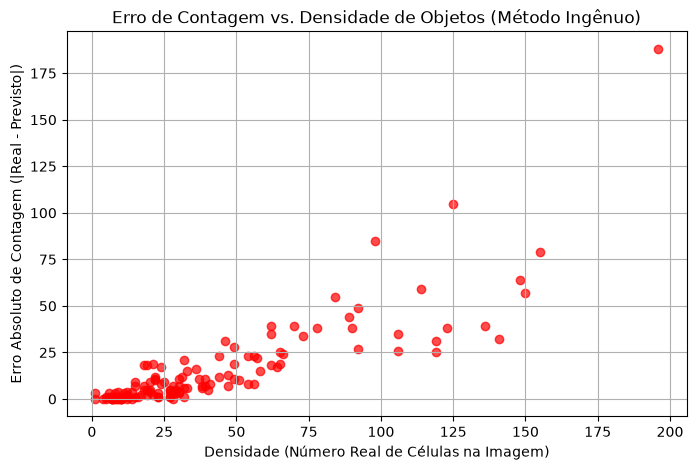

In [ ]:
ax_x_density = np.array(ax_x_density)
ax_y_error = np.array(ax_y_error)
plt.figure(figsize=(8, 5))
plt.scatter(ax_x_density[ax_x_density < 200], ax_y_error[ax_x_density < 200], alpha=0.7, color='red')
plt.title("Erro de Contagem vs. Densidade de Objetos (Método Ingênuo)")
plt.xlabel("Densidade (Número Real de Células na Imagem)")
plt.ylabel("Erro Absoluto de Contagem (|Real - Previsto|)")
plt.grid(True)
plt.show()

# Parte 2

In [16]:
def border_mask(mask, kernel_size=3):
    padding = kernel_size // 2

    # Obtem o minimo e o maximo na vizinhanca
    mask_float = mask.float()
    max_pool   = F.max_pool2d(mask_float, kernel_size=kernel_size, stride=1, padding=padding)
    min_pool   = -F.max_pool2d(-mask_float, kernel_size=kernel_size, stride=1, padding=padding)

    # Caso o minimo e o maximo sejam diferentes, eh fronteira
    mask_binary = binarize_mask(mask)
    mask_binary += torch.where(mask_binary != 0, (max_pool != min_pool).float(), 0.0)

    return mask_binary.long().squeeze(1) # Fronteira = 2, Interior = 1 e Fundo = 0

In [ ]:
def watershed_decoder(mask):
    images = mask.shape[0]
    # Considera somente regioes internas
    interior_mask = (mask == 1)

    # Monta as componentes conexas
    interior_mask = np.stack(
        [
            label(
                interior_mask[i].squeeze(0).cpu().numpy()
            )[0]
            for i in range(images)
        ]
    )

    # Expande (Watershed)
    cell_pixes = (mask != 0).float().cpu().numpy()
    image = np.zeros_like(interior_mask[0])
    return torch.stack(
        [
            torch.tensor(watershed(image=image, markers=interior_mask[i], mask=cell_pixes[i]))
            for i in range(images)
        ]
    ).unsqueeze(1)

# Funções auxiliares para usar na train_model()
def multiclass_watershed_decoder(pred_logits, **kwargs):
    pred_classes = torch.argmax(pred_logits, dim=1)
    return watershed_decoder(pred_classes)

def compute_instance_metrics_wrapper(pred_inst, mask_true_inst):
    pred_np = pred_inst.cpu().numpy()
    mask_true_np = mask_true_inst.cpu().numpy()

    intersect_matrix, iou_matrix = compute_intersection(mask_true_np, pred_np)

    if iou_matrix.shape == (1, 1): # Se não previu nada, o mAP é 0
        return {'map': 0.0, 'abs_err': 0.0}

    _, _, _, mean_ap, abs_err = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))

    return {'map': mean_ap, 'abs_err': abs_err}

In [18]:
def get_weights(loader, classes, transform_mask=None, device=None):
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    total_counts = torch.zeros(classes, dtype=torch.float64).to(device)
    with torch.no_grad():
        for i, (img, mask) in enumerate(loader):
            mask = mask.to(device)
            if not transform_mask is None:
                mask = transform_mask(mask)

            # Estava dando problema caso não tivesse uma das classes, coloquei um bincount pra contornar isso
            counts = torch.bincount(mask.flatten(), minlength=classes)
            total_counts += counts

    mx = total_counts.max()
    weights = mx / (total_counts + 1e-8)

    return weights.float()

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet(in_channels=3, out_channels=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
weight = get_weights(loader=train_dataloader, classes=3, transform_mask=border_mask)

train_model(
    model,
    loader_train=train_dataloader,
    loader_val=val_dataloader,
    optimizer=optimizer,
    epochs=30,
    loss=nn.CrossEntropyLoss(weight=weight),
    transform_mask=border_mask,
    decoder=multiclass_watershed_decoder,
    metric_function=compute_instance_metrics_wrapper,
    stop_metric='map',
    stop_threshold=0.99,
    patience=5,
    best_model_path="models/best_model_parte_02.pth",
    dim=1
)

Epoch [1/30] | Val Loss: 1.0761 | Train Loss: 0.7794
Val MAP: 0.0284 | Val ABS_ERR: 740.1418
Epoch [5/30] | Val Loss: 1.1240 | Train Loss: 0.4153
Val MAP: 0.0202 | Val ABS_ERR: 43.4552
Epoch [10/30] | Val Loss: 0.4558 | Train Loss: 0.3940
Val MAP: 0.2439 | Val ABS_ERR: 28.2239
Early stopping: Sem melhoria por 5 epocas consecutivas.
Train time: 13.784889264901478 minutes


[(0.7794129567987779,
  1.076083951526218,
  {'map': 0.028387651117711677, 'abs_err': 740.1417910447761}),
 (0.5522251374581281,
  0.9960524837176005,
  {'map': 0.010102198951982312, 'abs_err': 35.16417910447761}),
 (0.49652430064537945,
  0.9190578129556444,
  {'map': 0.01684840915446537, 'abs_err': 42.53731343283582}),
 (0.4263812005519867,
  0.5955812136332194,
  {'map': 0.0848383890664225, 'abs_err': 27.14179104477612}),
 (0.4152767439098919,
  1.1240404579374526,
  {'map': 0.020164471374668133, 'abs_err': 43.45522388059702}),
 (0.4109476576833164,
  0.4986404875914256,
  {'map': 0.24767623852672635, 'abs_err': 21.119402985074625}),
 (0.38499516073395224,
  0.8628184795379639,
  {'map': 0.029990782687951696, 'abs_err': 212.78358208955223}),
 (0.38848015315392437,
  0.4692043364048004,
  {'map': 0.18661265404662808, 'abs_err': 19.149253731343283}),
 (0.4200916544479482,
  1.0989178816477458,
  {'map': 0.01632279042973628, 'abs_err': 22.970149253731343}),
 (0.3939849383690778,
  0.45

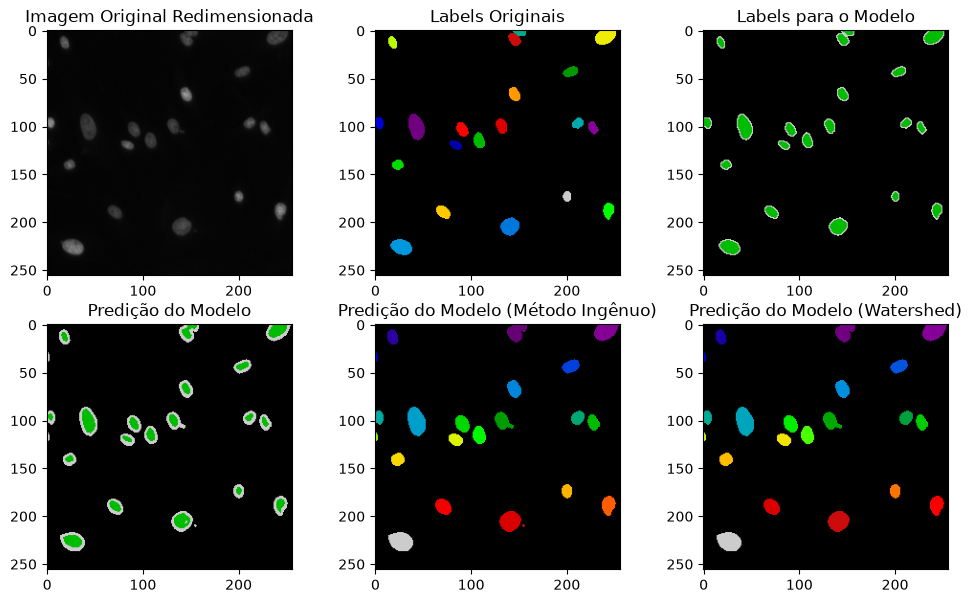

In [ ]:
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        img = img.to(device)
        mask = mask.to(device)
        mask_original = mask.clone()
        mask = border_mask(mask)
        
        # Desfaz a normalizacao da imagem
        img_plot = desnorm(img[0])

        pred = model(img)
        pred = multiclass_decoder(pred, dim=1).cpu().numpy().astype(int)
        # Componentes Conexas
        inst_matrix, num_obj = label(pred[0])
        
        # Watershed
        mask_watershed = watershed_decoder(torch.tensor(pred))
        
        fig, axes = plt.subplots(2, 3, figsize=(12, 7))
        axes = np.ravel(axes)
        axes[0].imshow(img_plot)
        axes[0].set(
            title="Imagem Original Redimensionada"
        )
        axes[1].imshow(mask_original[0][0].cpu().numpy(), cmap='nipy_spectral')
        axes[1].set(
            title="Labels Originais"
        )
        axes[2].imshow(mask[0].cpu().numpy(), cmap='nipy_spectral')
        axes[2].set(
            title="Labels para o Modelo"
        )
        axes[3].imshow(pred[0], cmap='nipy_spectral')
        axes[3].set(
            title="Predição do Modelo"
        )
        axes[4].imshow(inst_matrix, cmap='nipy_spectral')
        axes[4].set(
            title="Predição do Modelo (Método Ingênuo)"
        )
        axes[5].imshow(mask_watershed[0][0], cmap='nipy_spectral')
        axes[5].set(
            title="Predição do Modelo (Watershed)"
        )
        break

# Parte 3

Aqui, optamos por seguir com os Eixos 1 (Pool indices e Skip connections) e 2

In [32]:
# Eixo 1: SegNet
class SegNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(SegNet, self).__init__()
        # Encoder (Igual ao da UNet)
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2, return_indices=True)

        # Bottleneck
        self.bottleneck = DoubleConv(128,256)

        # Decoder
        self.unpool1 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.unpool2 = nn.MaxUnpool2d(kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        x = self.conv1(x)
        x, idx1 = self.pool1(x)
        x = self.conv2(x)
        x, idx2 = self.pool2(x)

        x = self.bottleneck(x)

        x = self.dec1(x)
        x = self.unpool1(x,idx2)
        x = self.dec2(x)
        x = self.unpool2(x,idx1)

        return self.final_conv(x)

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [ ]:
resultados_mAP = [[],[]]
weight = get_weights(loader=train_dataloader, classes=3, transform_mask=border_mask)

for seed in [3,20]:
    set_seed(seed)

    # Treino do modelo
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = UNet(in_channels=3, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    metrics = train_model(
        model,
        loader_train=train_dataloader,
        loader_val=val_dataloader,
        optimizer=optimizer,
        epochs=1,
        loss=nn.CrossEntropyLoss(weight=weight),
        transform_mask=border_mask,
        decoder=multiclass_watershed_decoder,
        metric_function=compute_instance_metrics_wrapper,
        stop_metric='map',
        stop_threshold=0.99,
        patience=5,
        best_model_path="models/best_model_parte_03_01_UNet.pth",
        dim=1
    )

    best_map = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
    resultados_mAP[0].append(best_map)

    # Treino do modelo
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SegNet(in_channels=3, out_channels=3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    metrics = train_model(
        model,
        loader_train=train_dataloader,
        loader_val=val_dataloader,
        optimizer=optimizer,
        epochs=1,
        loss=nn.CrossEntropyLoss(weight=weight),
        transform_mask=border_mask,
        decoder=multiclass_watershed_decoder,
        metric_function=compute_instance_metrics_wrapper,
        stop_metric='map',
        stop_threshold=0.99,
        patience=5,
        best_model_path="models/best_model_parte_03_01_SegNet.pth",
        dim=1
    )

    best_map = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
    resultados_mAP[1].append(best_map)

print(f"\nResultados do Eixo 1:")
print(f"UNet: Media {np.mean(resultados_mAP[0])} Desvio Padrão {np.std(resultados_mAP[0])}")
print(f"SegNet: Media {np.mean(resultados_mAP[1])} Desvio Padrão {np.std(resultados_mAP[1])}")

In [19]:
# Eixo 2: Baseline (CE) -> Ablação 1 (CE balanceada) -> Ablação 2 (Focal) -> Ablação 3 (Focal balanceada)
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2):
        super(FocalLoss, self).__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = (1-pt)**self.gamma * ce_loss
        return focal_loss.mean()

In [ ]:
resultados_mAP = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resultados_eixo2 = {
    'sem_peso': {0: [], 1: [], 2: [], 5: []},
    'com_peso': {0: [], 1: [], 2: [], 5: []}
}

# Auxiliares pra não ter que retreinar o modelo o tempo todo
global_best_map = 0.0
caminho_melhor_modelo = "models/best_model_parte_03_02.pth"

for balanceado in [False, True]:
    chave_peso = 'com_peso' if balanceado else 'sem_peso'

    # Calcula os pesos uma única vez por configuração
    if balanceado:
        weight = get_weights(loader=train_dataloader, classes=3, transform_mask=border_mask)
    else:
        weight = None

    for gamma in [0, 1, 2, 5]:

        for seed in [23, 24]:
            set_seed(seed)

            model = UNet(in_channels=3, out_channels=3).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

            # gamma = 0 vira a Cross Entropy pura
            if gamma == 0:
                loss_fn = nn.CrossEntropyLoss(weight=weight)
            else:
                loss_fn = FocalLoss(weight=weight, gamma=gamma)

            metrics = train_model(
                model,
                loader_train=train_dataloader,
                loader_val=val_dataloader,
                optimizer=optimizer,
                epochs=50,
                loss=loss_fn,
                transform_mask=border_mask,
                decoder=multiclass_watershed_decoder,
                metric_function=compute_instance_metrics_wrapper,
                monitor_metric='map',
                stop_threshold=0.99,
                patience=10,
                best_model_path="models/best_model_parte_03_02.pth",
                dim=1
            )

            # Extrai o melhor mAP dessa rodada específica
            best_map_rodada = max([epoch_data[2].get('map', 0) for epoch_data in metrics])
            resultados_eixo2[chave_peso][gamma].append(best_map_rodada)

            if best_map_rodada > global_best_map:
                print(f"Modelo melhor encontrado: {best_map_rodada:.4f}")
                global_best_map = best_map_rodada
                torch.save(model.state_dict(), caminho_melhor_modelo)

print("\n==================================================================")

for balanceado in [False, True]:
    chave = 'com_peso' if balanceado else 'sem_peso'
    print(f"\n--- {chave.upper()} ---")

    # Gamma 0 (Cross Entropy)
    media_ce = np.mean(resultados_eixo2[chave][0])
    std_ce = np.std(resultados_eixo2[chave][0], ddof=1)
    print(f"CE: Média {media_ce:.4f} ± {std_ce:.4f}")

    # Focal Loss (Gammas 1, 2, 5)
    for gamma in [1, 2, 5]:
        media_fl = np.mean(resultados_eixo2[chave][gamma])
        std_fl = np.std(resultados_eixo2[chave][gamma], ddof=1)
        print(f"Focal (y={gamma}): Média {media_fl:.4f} ± {std_fl:.4f}")

print(f"\nO melhor modelo atingiu mAP de {global_best_map:.4f} e foi salvo em: {caminho_melhor_modelo}")

In [26]:
def load_best_model(path):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = UNet(in_channels=3, out_channels=3).to(device)
    path_weights = path
    weights = torch.load(path_weights, map_location=device, weights_only=True)
    model.load_state_dict(weights)
    model.eval()

    return model

# Parte 4

In [ ]:
def tiles_mask(mask, tamanho_janela=256, stride=128, mk_grid=True):
    # Junta as images do batch num unico grid, caso ela ja nao venha como uma imagem sobig_mask = mask.clone()
    if mk_grid:
        c = mask.shape[1]
        big_mask = make_grid(mask, nrow=4, padding=0)[:c, :, :]
    else:
        big_mask = mask.squeeze(0).clone()
    
    # Obtem os recortes com stride e tamanho de janela definidos, empurrando as dimensoes extras para o tamanho do novo batch
    return torch.cat(
        [
            channel
            .unfold(0, tamanho_janela, stride)
            .unfold(1, tamanho_janela, stride)
            .contiguous()
            .view(-1, 1, tamanho_janela, tamanho_janela)
            for channel in big_mask
        ],
        dim=1
    )

In [ ]:
def tiles_unmask(mask, tamanho_imagem=[1024, 1024], tamanho_janela=256, stride=128):
    unmask = mask.contiguous().view(mask.size(0), -1).transpose(0, 1).unsqueeze(0)
    
    # Desfaz o Unfold, somando as fronteiras compartilhadas
    unmask_sum = F.fold(
        unmask, 
        output_size=tamanho_imagem, 
        kernel_size=tamanho_janela, 
        stride=stride
    )
    
    # Faz a contagem de intersecoes
    ones_flat = torch.ones_like(unmask)
    count = F.fold(
        ones_flat, 
        output_size=tamanho_imagem, 
        kernel_size=tamanho_janela, 
        stride=stride
    )
    
    # Dividir para obter a media suave nas bordas
    return unmask_sum / count

In [ ]:
def tiles_naive_unmask(mask, tamanho_imagem=[1024, 1024], tamanho_janela=256, stride=128):
    tamanho_imagem = np.asarray(tamanho_imagem).astype(int)
    mod = ((tamanho_imagem / stride) - 1).astype(int)
    
    naive_mask = torch.zeros(size=tuple(tamanho_imagem))
    
    start_y = 0
    end_y   = tamanho_janela
    current = 0
    for each_row in range(mod[0]):
        start_mask_row = (tamanho_janela - stride) * (each_row != 0) 
        start_x        = 0
        end_x          = tamanho_janela
        for each_col in range(mod[1]):
            start_mask_col = (tamanho_janela - stride) * (each_col != 0) 
                
            naive_mask[start_y:end_y, start_x:end_x] += mask[current, 0, start_mask_row:, start_mask_col:]
            
            start_x  = end_x
            end_x   += stride
            current += 1
                
        start_y = end_y
        end_y  += stride
        
    return naive_mask.unsqueeze(0).unsqueeze(1)

In [ ]:
def map_to_seq(mask):
    uniques   = torch.unique(mask[mask != -1]).cpu().numpy()
    idxs      = np.arange(uniques.size) + (0 not in uniques)
    map_front = {u: i for u, i in zip(uniques, idxs)}
    map_inv   = {i: u for u, i in zip(uniques, idxs)}
    return map_front, map_inv
    

def fusion(intersect_ant, intersect_pos, next_class):
    intersect_ant = intersect_ant.clone()
    intersect_pos = intersect_pos.clone()
    
    # Faz um map das classes para numeros sequencias
    map_ant_front, map_ant_inv = map_to_seq(intersect_ant)
    map_pos_front, map_pos_inv = map_to_seq(intersect_pos)
    
    # Calcula a matriz de iou e os matches
    _, iou_matrix = compute_intersection(mask_true=intersect_ant, mask_pred=intersect_pos)

    iou = iou_matrix[1:, 1:]
    predicts, trues = iou.shape
    matches_iou, matches = greedy_match(iou, predicts, trues)
    
    # Retorna o match com as classes originais
    matches_fusion = {}
    for pos, ant in enumerate(matches):
        pos = -1 if pos is None else map_pos_inv[pos+1]
        ant = -1 if ant is None else map_ant_inv[ant+1]
        if ant == -1:
            matches_fusion[pos] = next_class
            next_class += 1
        else:
            matches_fusion[pos] = ant
    
    return matches_fusion, next_class
    
    
    
def inst_fusion(pred, tamanho_imagem=[1024, 1024], stride=128):
    pred = pred.clone()
    height, width = pred.shape[-2:]
    
    # Calcula a quantidade de tiles por eixo
    tamanho_imagem = np.asarray(tamanho_imagem).astype(int)
    mod            = ((tamanho_imagem / stride) - 1).astype(int)
    
    current    = 0
    next_class = 0
    for each_row in range(mod[0]):
        # Em cada recorte, avalia as intersecoes anteriores (a esquerda, em cima e a em cima/esquerda)
        for each_col in range(mod[1]):
            if not any([each_col, each_row]):
                current   += 1
                next_class = pred[0, 0].max() + 1
                continue
            
            # Calcula os indices dos sucessoros
            sup_esq = sup = esq = None
            if each_row:
                sup     = (current - mod[1])
                sup_esq = (sup - 1) if each_col else None
            if each_col:
                esq = (current - 1)
            
            # Constroi uma mask com os ids ja selecionados
            ant_pred     = torch.full_like(pred[0], fill_value=0)
            pred_current = torch.full_like(pred[0], fill_value=0)
            for ant_idx, (is_ant_esq, is_ant_sup) in zip(
                [sup_esq, sup, esq],
                [(True, True), (False, True), (True, False)]
            ):
                if ant_idx is None: continue
                stride_x = (stride * int(is_ant_esq))
                stride_y = (stride * int(is_ant_sup))
                ant_pred[0, :(height-stride_y), :(width-stride_x)]     = pred[ant_idx, 0, stride_y:, stride_x:]
                pred_current[0, :(height-stride_y), :(width-stride_x)] = pred[current, 0, :(height-stride_y), :(width-stride_x)]
            
            # Processa as intersecoes com a regiao ja selecionada, trocando os ids de acordo com os matchings
            matches_fusion, next_class = fusion(ant_pred, pred_current, next_class)
            for each_pred, each_ant in matches_fusion.items():
                pred[current, 0] = torch.where(pred[current, 0] == each_pred, each_ant, pred[current, 0])
            
            current += 1
        
    return pred

In [ ]:
def globalize_ids(mask):
    mxs = mask.flatten(1).max(dim=1).values
    acc_sum = torch.cat([torch.zeros(1, dtype=mxs.dtype, device=mask.device), torch.cumsum(mxs, dim=0)[:-1]])
    nao_fundo = (mask != 0)
    return torch.where(nao_fundo, mask + acc_sum.view(-1, 1, 1, 1), mask)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.0385313..3.4927626].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.827907..3.6934962].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.3099627..2.8326674].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.9280322..4.395603].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-8.214258..4.457767].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.656017..4.457767].
C:\Users\user\AppData\Local\Temp\ipykernel_6872\4146878938.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be sh

Previsão ANTES da fusão: 
mAP: 0.13016758056888955 
ABS Error: 227.0
Previsão DEPOIS da fusão: 
mAP: 0.14517745189551792 
ABS Error: 126.0


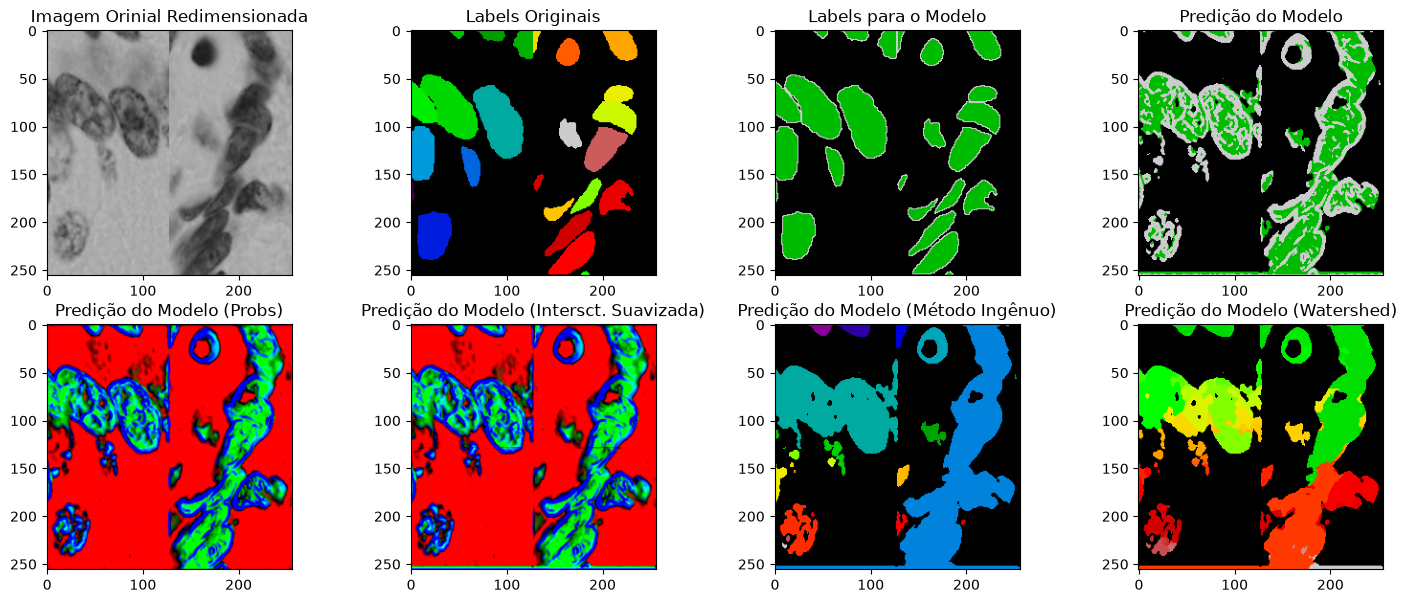

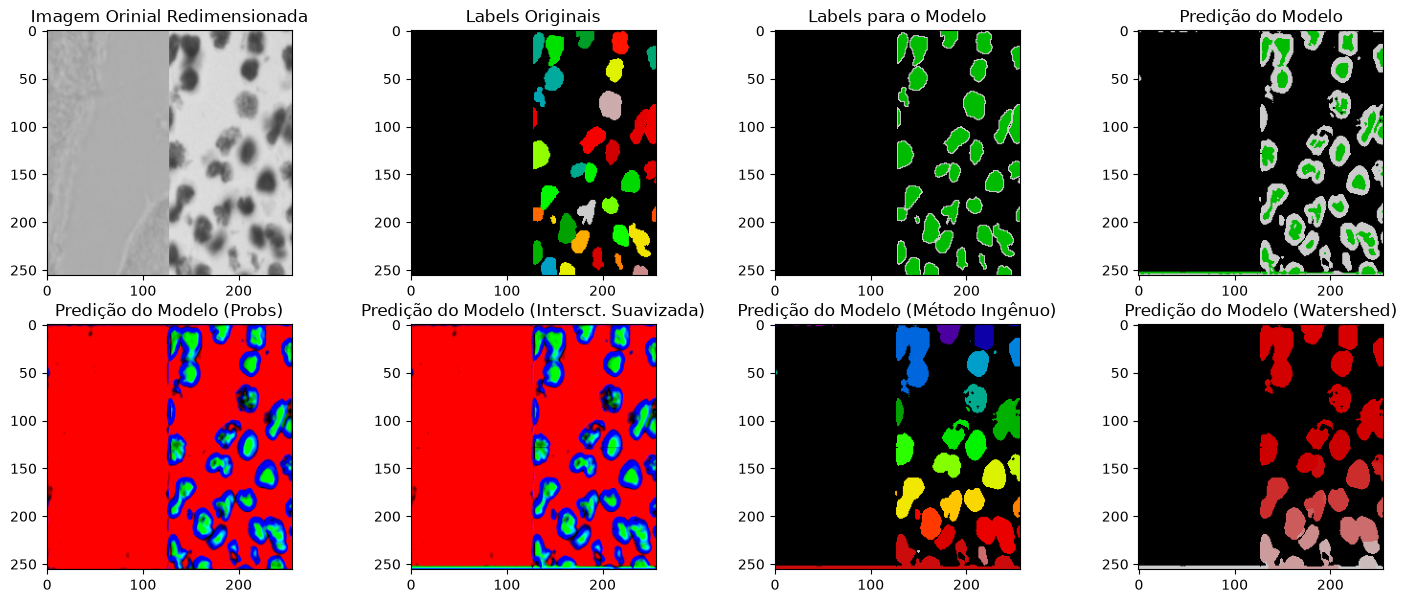

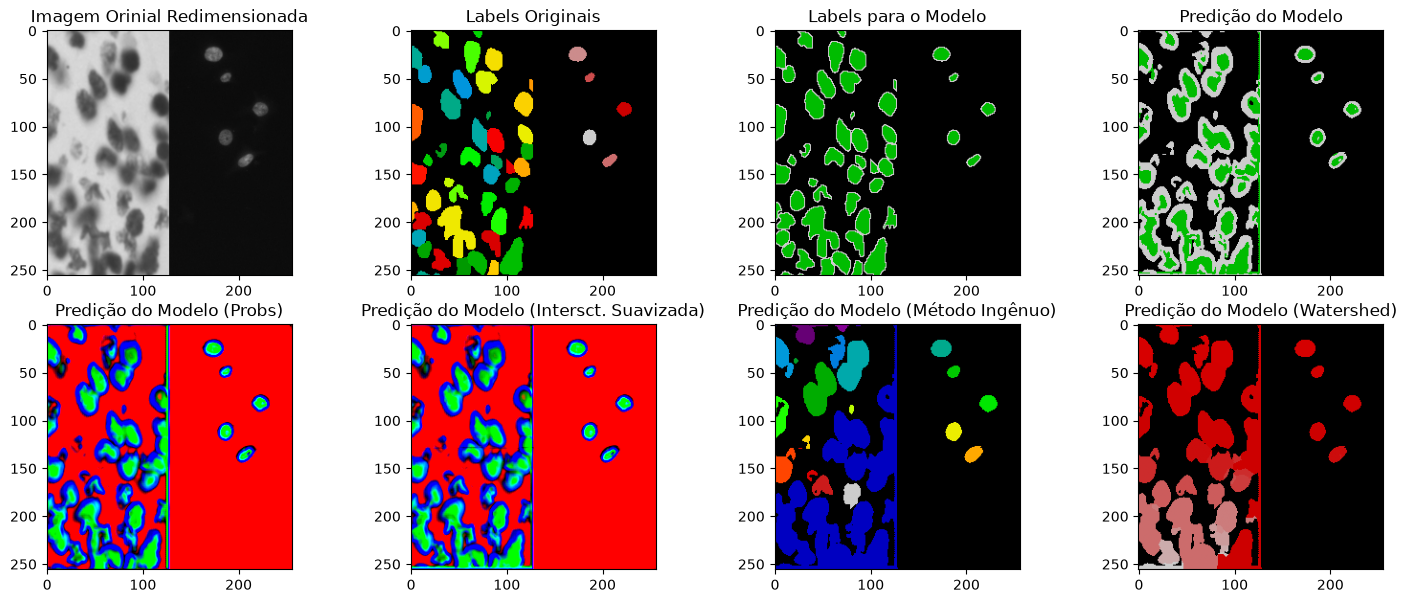

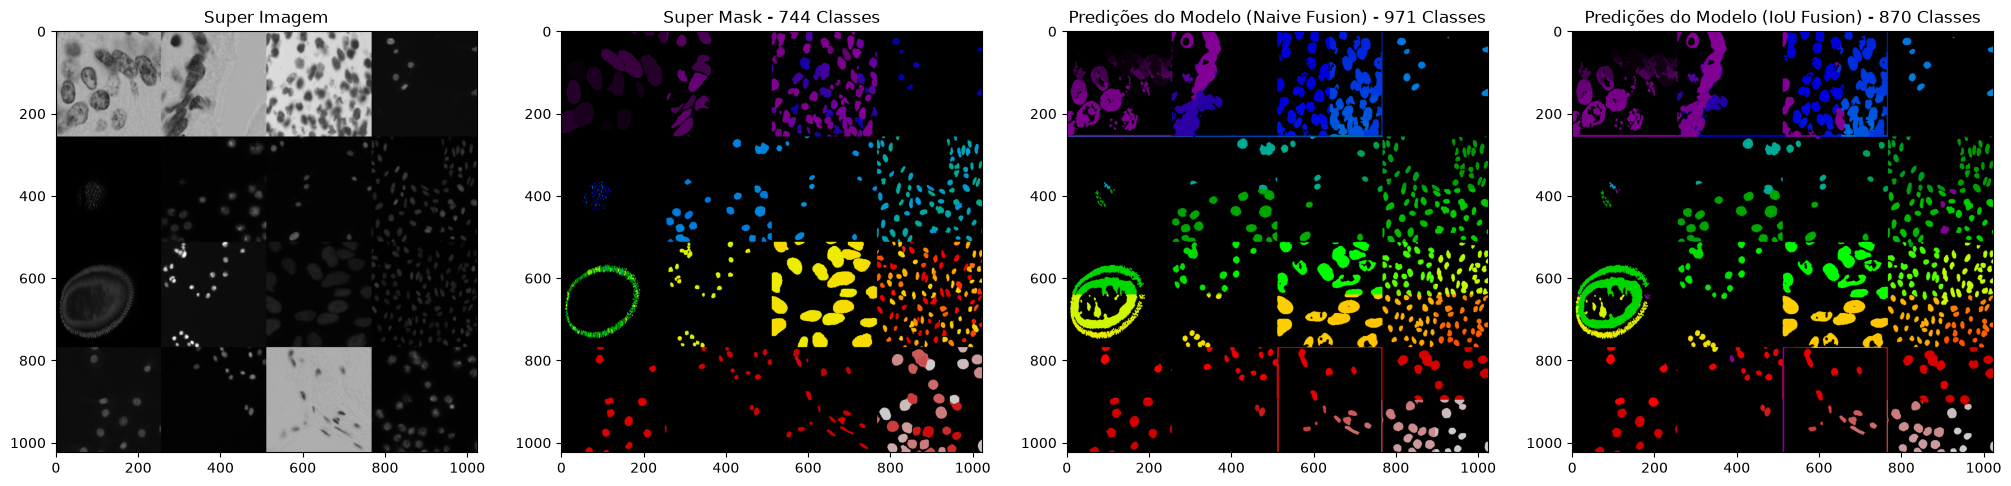

In [ ]:
with torch.no_grad():
    for i, (img, mask) in enumerate(val_dataloader):
        if mask.shape[0] != batch_size: continue
        img = img.to(device)
        mask = mask.to(device)
        
        # Converte id local em id global
        mask = globalize_ids(mask)
        
        # Obtem recortes ao unir as imagens do batch numa grande imagem como grid
        tamanho_janela = 256 
        stride         = 128
        img            = tiles_mask(img, tamanho_janela=tamanho_janela, stride=stride)
        mask           = tiles_mask(mask, tamanho_janela=tamanho_janela, stride=stride)
        
        pred          = model(img)
        pred_original = pred.clone()
        mask_original = mask.clone()
        mask          = border_mask(mask)
        
        # Agrupa as predicoes para suavizar as bordas
        big_pred  = tiles_unmask(pred.clone(), tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, tamanho_janela=tamanho_janela, stride=stride)
        pred      = tiles_mask(big_pred, tamanho_janela=tamanho_janela, stride=stride, mk_grid=False)
        pred_suav = pred.clone()
        pred      = multiclass_decoder(pred, dim=1).int()
        
        # Watershed
        mask_watershed = watershed_decoder(pred)
        mask_watershed = globalize_ids(mask_watershed)
        pred           = pred.unsqueeze(1).cpu().numpy().astype(int)
        
        for b in range(mask.shape[0]):
            if (b // 7 + b % 2) == 0: continue
            # Desfaz a normalizacao da imagem
            img_plot = desnorm(img[b])

            # Componentes Conexas
            inst_matrix, num_obj = label(pred[b][0])
            
            fig, axes = plt.subplots(2, 4, figsize=(18, 7))
            axes = np.ravel(axes)
            axes[0].imshow(img_plot)
            axes[0].set(
                title="Imagem Original Redimensionada"
            )
            axes[1].imshow(mask_original[b][0].cpu().numpy(), cmap='nipy_spectral')
            axes[1].set(
                title="Labels Originais"
            )
            axes[2].imshow(mask[b].cpu().numpy(), cmap='nipy_spectral')
            axes[2].set(
                title="Labels para o Modelo"
            )
            axes[3].imshow(pred[b][0], cmap='nipy_spectral')
            axes[3].set(
                title="Predição do Modelo"
            )
            axes[4].imshow(pred_original[b].permute(1, 2, 0).cpu().numpy(), cmap='nipy_spectral')
            axes[4].set(
                title="Predição do Modelo (Probs)"
            )
            axes[5].imshow(pred_suav[b].permute(1, 2, 0).cpu().numpy(), cmap='nipy_spectral')
            axes[5].set(
                title="Predição do Modelo (Intersct. Suavizada)"
            )
            axes[6].imshow(inst_matrix, cmap='nipy_spectral')
            axes[6].set(
                title="Predição do Modelo (Método Ingênuo)"
            )
            axes[7].imshow(mask_watershed[b][0], cmap='nipy_spectral')
            axes[7].set(
                title="Predição do Modelo (Watershed)"
            )
            if b > 3: break 
            
        fig.show()
        fig2, axes2  = plt.subplots(1, 4, figsize=(25, 7))
        axes2        = np.ravel(axes2)
        super_imagem = torch.cat([tiles_naive_unmask(img[:, c].unsqueeze(1).cpu()) for c in range(3)], axis=1)[0]
        super_imagem = torch.tensor(desnorm(super_imagem))
        axes2[0].imshow(super_imagem)
        axes2[0].set(
            title="Super Imagem"
        )
        
        super_mask = tiles_naive_unmask(
            mask_original.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        axes2[1].imshow(
            super_mask, 
            cmap='nipy_spectral'
        )
        axes2[1].set(
            title=f"Super Mask - {torch.unique(super_mask).numel() - 1} Classes"
        )
        
        super_naive_pred = tiles_naive_unmask(
            mask_watershed.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        axes2[2].imshow(
            super_naive_pred, 
            cmap='nipy_spectral'
        )
        axes2[2].set(
            title=f"Predições do Modelo (Naive Fusion) - {torch.unique(super_naive_pred).numel() - 1} Classes"
        )
        
        solucao_iou_fusion = inst_fusion(mask_watershed)
        super_iou_pred = tiles_naive_unmask(
            solucao_iou_fusion.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        axes2[3].imshow(
            super_iou_pred, 
            cmap='nipy_spectral'
        )
        axes2[3].set(
            title=f"Predições do Modelo (IoU Fusion) - {torch.unique(super_iou_pred).numel() - 1} Classes"
        )
        
        break

In [ ]:
with torch.no_grad():
    true_positives  = {"Previsão ANTES da fusão": [], "Previsão DEPOIS da fusão": []}
    false_positives = {"Previsão ANTES da fusão": [], "Previsão DEPOIS da fusão": []}
    false_negatives = {"Previsão ANTES da fusão": [], "Previsão DEPOIS da fusão": []}
    
    for i, (img, mask) in enumerate(val_dataloader):
        if mask.shape[0] != batch_size: continue
        img = img.to(device)
        mask = mask.to(device)
        
        # Converte id local em id global
        mask = globalize_ids(mask)
        
        # Obtem recortes ao unir as imagens do batch numa grande imagem como grid
        tamanho_janela = 256 
        stride         = 128
        img            = tiles_mask(img, tamanho_janela=tamanho_janela, stride=stride)
        mask           = tiles_mask(mask, tamanho_janela=tamanho_janela, stride=stride)
        
        pred          = model(img)
        pred_original = pred.clone()
        mask_original = mask.clone()
        mask          = border_mask(mask)
        
        # Agrupa as predicoes para suavizar as bordas
        big_pred  = tiles_unmask(pred.clone(), tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, tamanho_janela=tamanho_janela, stride=stride)
        pred      = tiles_mask(big_pred, tamanho_janela=tamanho_janela, stride=stride, mk_grid=False)
        pred_suav = pred.clone()
        pred      = multiclass_decoder(pred, dim=1).int()
        
        # Watershed
        mask_watershed = watershed_decoder(pred)
        mask_watershed = globalize_ids(mask_watershed)
        pred           = pred.unsqueeze(1).cpu().numpy().astype(int)
        
        
        # Agrega os batches de mascaras e previsoes em um unico grid cada
        super_mask = tiles_naive_unmask(
            mask_original.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        
        super_naive_pred = tiles_naive_unmask(
            mask_watershed.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        
        solucao_iou_fusion = inst_fusion(mask_watershed)
        super_iou_pred = tiles_naive_unmask(
            solucao_iou_fusion.float().cpu(), 
            tamanho_imagem=np.array([tamanho_janela, tamanho_janela])*4, 
            tamanho_janela=tamanho_janela, 
            stride=stride
        )[0][0]
        
        # Computa as metricas (map e abs error) antes e depois da fusao de instancias
        for super_pred, descricao in zip(
            [super_naive_pred, super_iou_pred], 
            ["Previsão ANTES da fusão", "Previsão DEPOIS da fusão"]
        ):
            _, iou_matrix = compute_intersection(mask_true=super_mask, mask_pred=super_pred)
            tp, fp, fn, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))
            true_positives[descricao].append(tp)
            false_positives[descricao].append(fp)
            false_negatives[descricao].append(fn)
            
    # Agrega as metricas finais
    for descricao in ["Previsão ANTES da fusão", "Previsão DEPOIS da fusão"]:
        tp = np.sum(true_positives[descricao], axis=0)
        fp = np.sum(false_positives[descricao], axis=0)
        fn = np.sum(false_negatives[descricao], axis=0)
        
        mean_average_precision = tp / (tp + fp + fn)
        plt.plot(np.arange(0.5, 1, 0.05), mean_average_precision, label=descricao)

    plt.xlabel("Limiar de IoU")        
    plt.ylabel("mAP")        
    plt.title("Curva de degradação do mAP ANTES e DEPOIS da fusão por IoU")  
    plt.legend()

# Parte 5

In [27]:
# Primeiro, vamos calcular a distribuição de tamanhos dos objetos do dataset e o campo receptivo teórico do encoder
# Para o campo receptivo do encoder, usamos como base o pseudocódigo do link: https://www.baeldung.com/cs/cnn-receptive-field-size (que eu descobri depois que estava errado ;-;, mas já corrigi!)

def compute_receptive_field(k, s, L=2):
    r = 1

    for l in range(1,L+1):
        S = 1

        for i in range(1,l):
            S *= s[i-1]

        r += (k[l-1]-1)*S

    return r


def compute_objects_size_distribution(dataloader):
    sizes = []

    max_size = 0
    max_img = None
    max_mask = None

    min_size = float('inf')
    min_img = None
    min_mask = None

    for img, mask_original in dataloader:
        for i in range(mask_original.shape[0]):
            mask = mask_original[i].squeeze(0).cpu().numpy()
            classes = np.unique(mask)

            for each_class in classes:
                if not each_class:
                    continue

                xs, ys = np.where(mask == each_class)
                height = ys.max() - ys.min() + 1
                width = xs.max() - xs.min() + 1

                current_size = max(height, width)
                sizes.append(current_size)

                if current_size > max_size:
                    max_size = current_size
                    max_img = img[i]
                    max_mask = mask

                if current_size < min_size:
                    min_size = current_size
                    min_img = img[i]
                    min_mask = mask

    return sizes, max_size, max_img, max_mask, min_size, min_img, min_mask


Campo Receptivo Teórico: 32
Distribuição das imagens: Tamanho mínimo: 1 | Tamanho máximo: 90


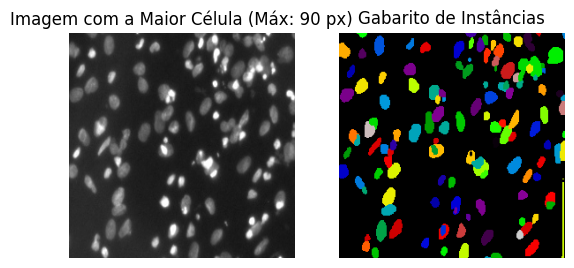

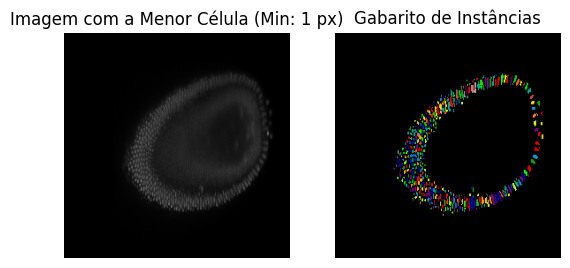

In [29]:
kernels = [3, 3, 2, 3, 3, 2, 3, 3]
strides = [1, 1, 2, 1, 1, 2, 1, 1]
r0 = compute_receptive_field(kernels, strides, L=8)
cell_sizes, max_size, max_img, max_mask,  min_size, min_img, min_mask = compute_objects_size_distribution(val_dataloader)
print(f"Campo Receptivo Teórico: {r0}")
print(f"Distribuição das imagens: Tamanho mínimo: {min(cell_sizes)} | Tamanho máximo: {max(cell_sizes)}")

# Plot pra verificar se é tão grande mesmo
img_plot = max_img.cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_plot = (img_plot * std) + mean
img_plot = np.clip(img_plot, 0, 1)

fig, axes = plt.subplots(1, 2)

axes[0].imshow(img_plot)
axes[0].set_title(f"Imagem com a Maior Célula (Máx: {max_size} px)")
axes[0].axis('off')

axes[1].imshow(max_mask, cmap='nipy_spectral')
axes[1].set_title("Gabarito de Instâncias")
axes[1].axis('off')

plt.show()

# Plot pra verificar se é tão pequeno mesmo
img_plot = min_img.cpu().permute(1, 2, 0).numpy()
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_plot = (img_plot * std) + mean
img_plot = np.clip(img_plot, 0, 1)

fig, axes = plt.subplots(1, 2)

axes[0].imshow(img_plot)
axes[0].set_title(f"Imagem com a Menor Célula (Min: {min_size} px)")
axes[0].axis('off')

axes[1].imshow(min_mask, cmap='nipy_spectral')
axes[1].set_title("Gabarito de Instâncias")
axes[1].axis('off')

plt.show()

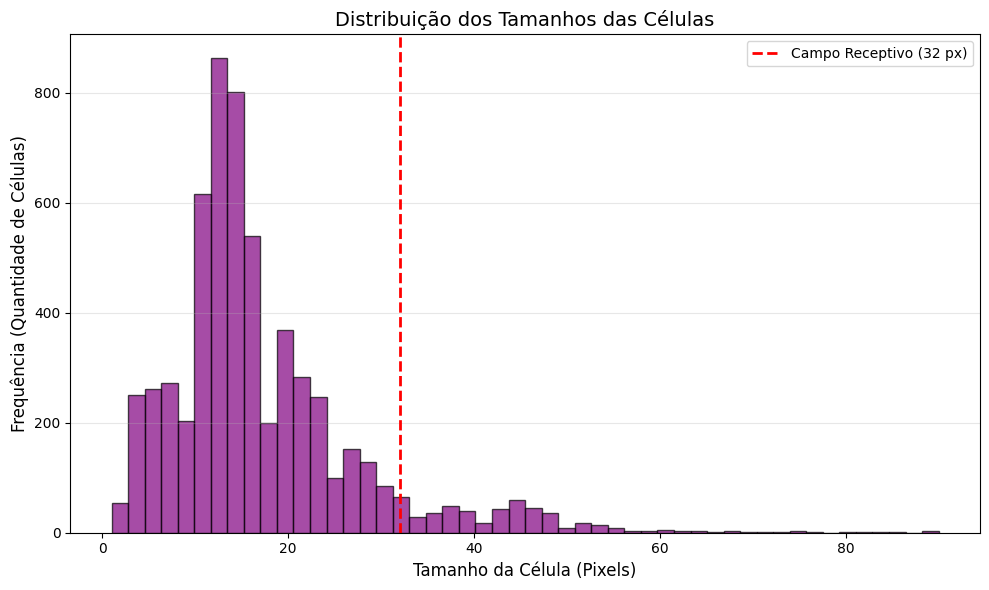

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plotagem do histograma
plt.hist(cell_sizes, bins=50, color='purple', edgecolor='black', alpha=0.7)

plt.title('Distribuição dos Tamanhos das Células', fontsize=14)
plt.xlabel('Tamanho da Célula (Pixels)', fontsize=12)
plt.ylabel('Frequência (Quantidade de Células)', fontsize=12)
plt.axvline(x=r0, color='red', linestyle='--', linewidth=2, label=f'Campo Receptivo ({r0} px)')

plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [37]:
# Carregando o melhor modelo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = load_best_model("melhor_modelo.pth")


Avaliação do Pior Caso #1 | mAP: 0.0000


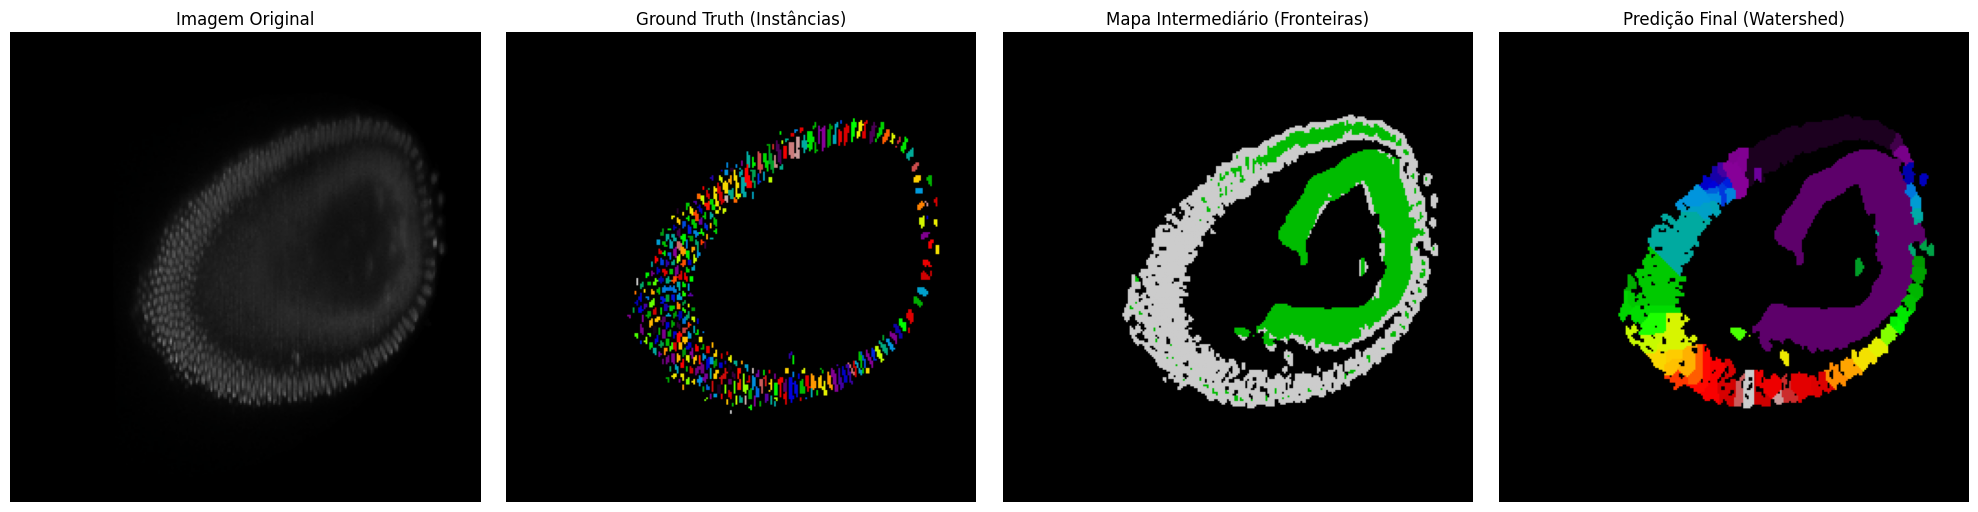


Avaliação do Pior Caso #2 | mAP: 0.0040


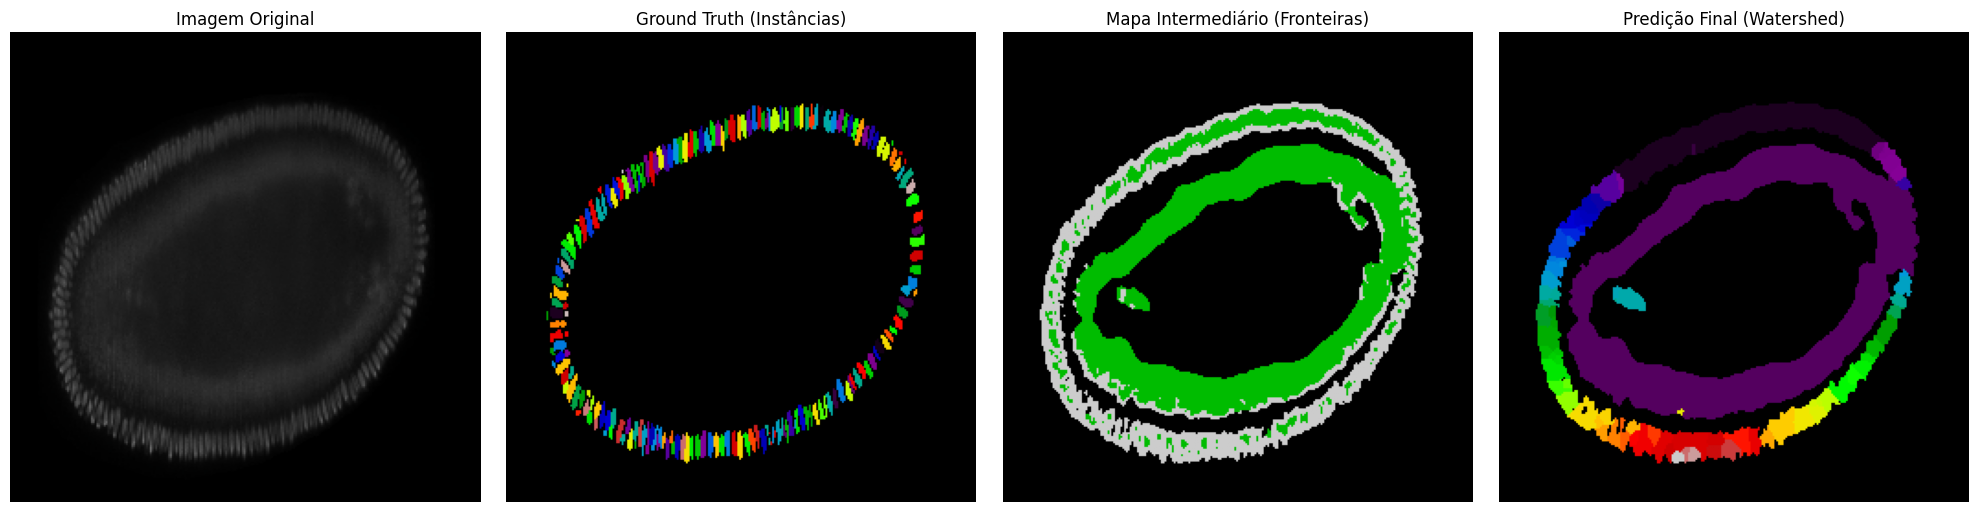


Avaliação do Pior Caso #3 | mAP: 0.0052


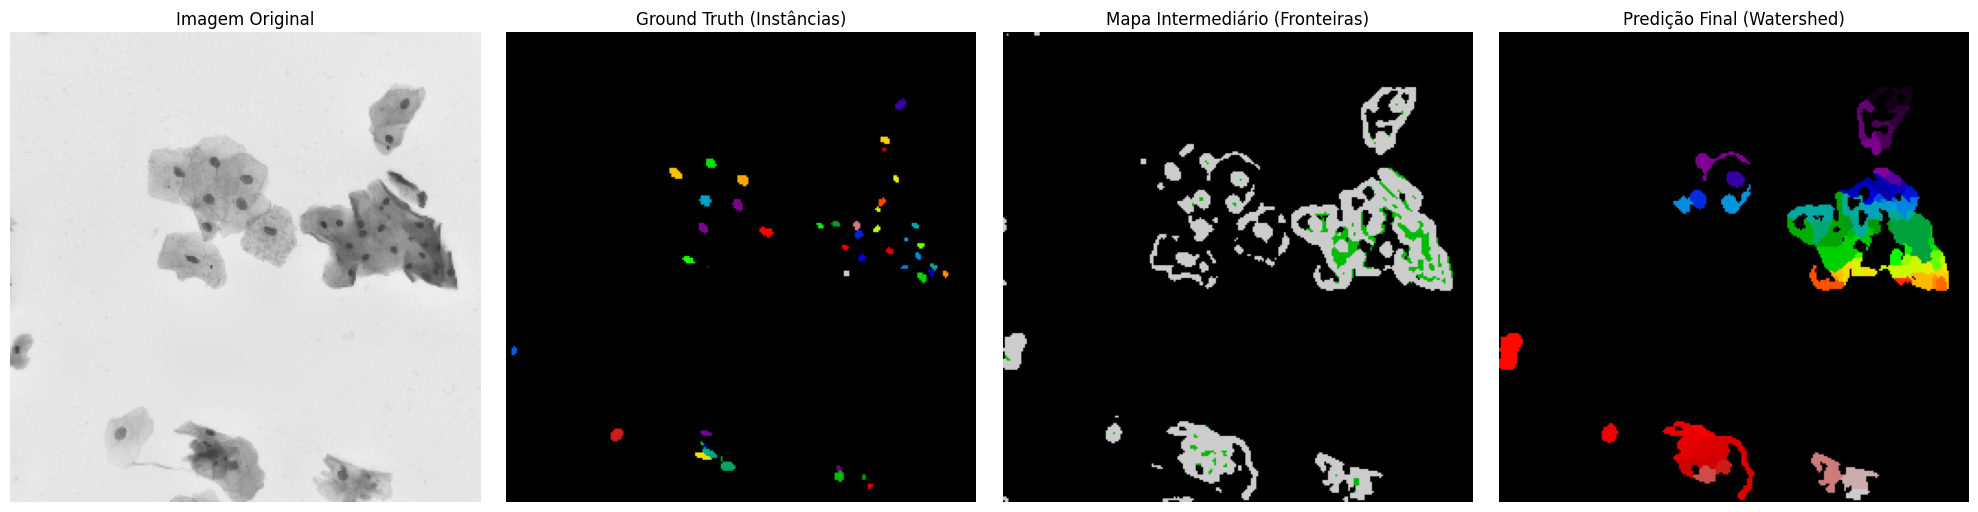


Avaliação do Pior Caso #4 | mAP: 0.0087


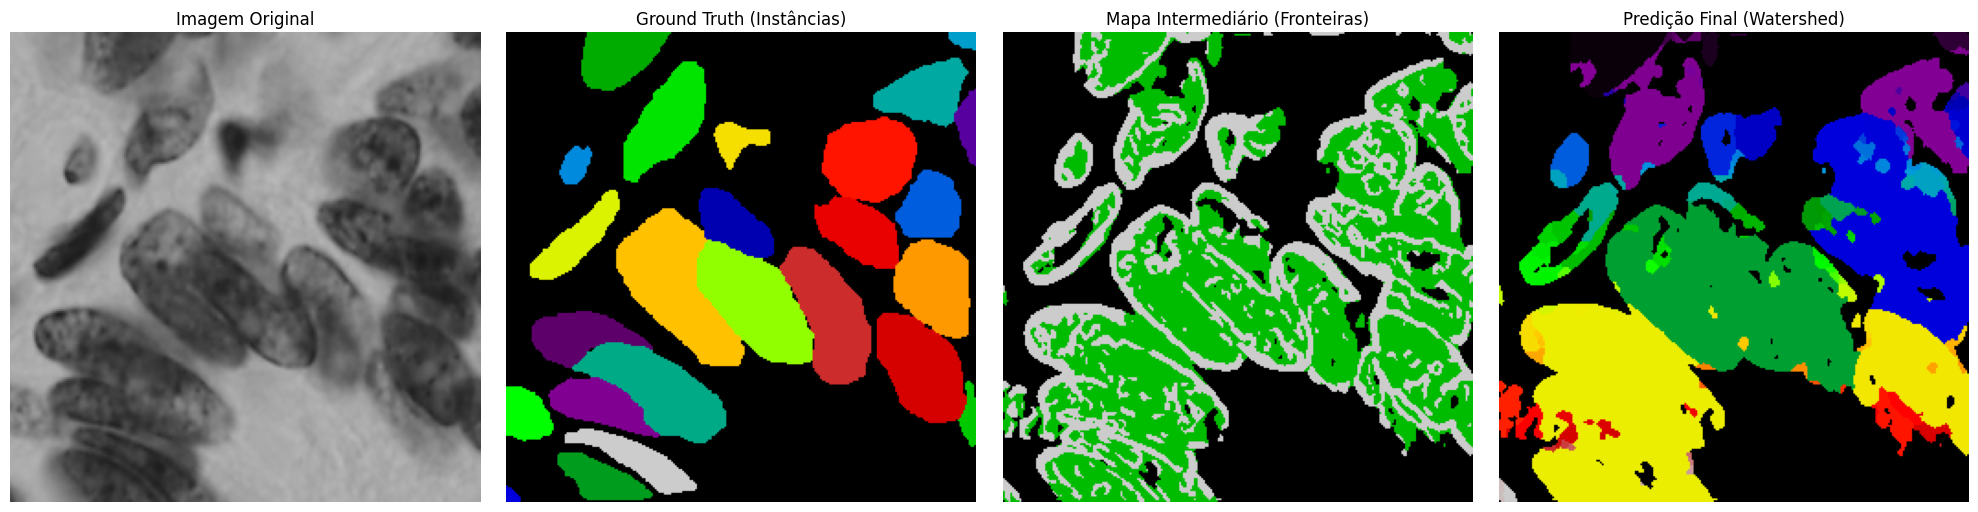


Avaliação do Pior Caso #5 | mAP: 0.0126


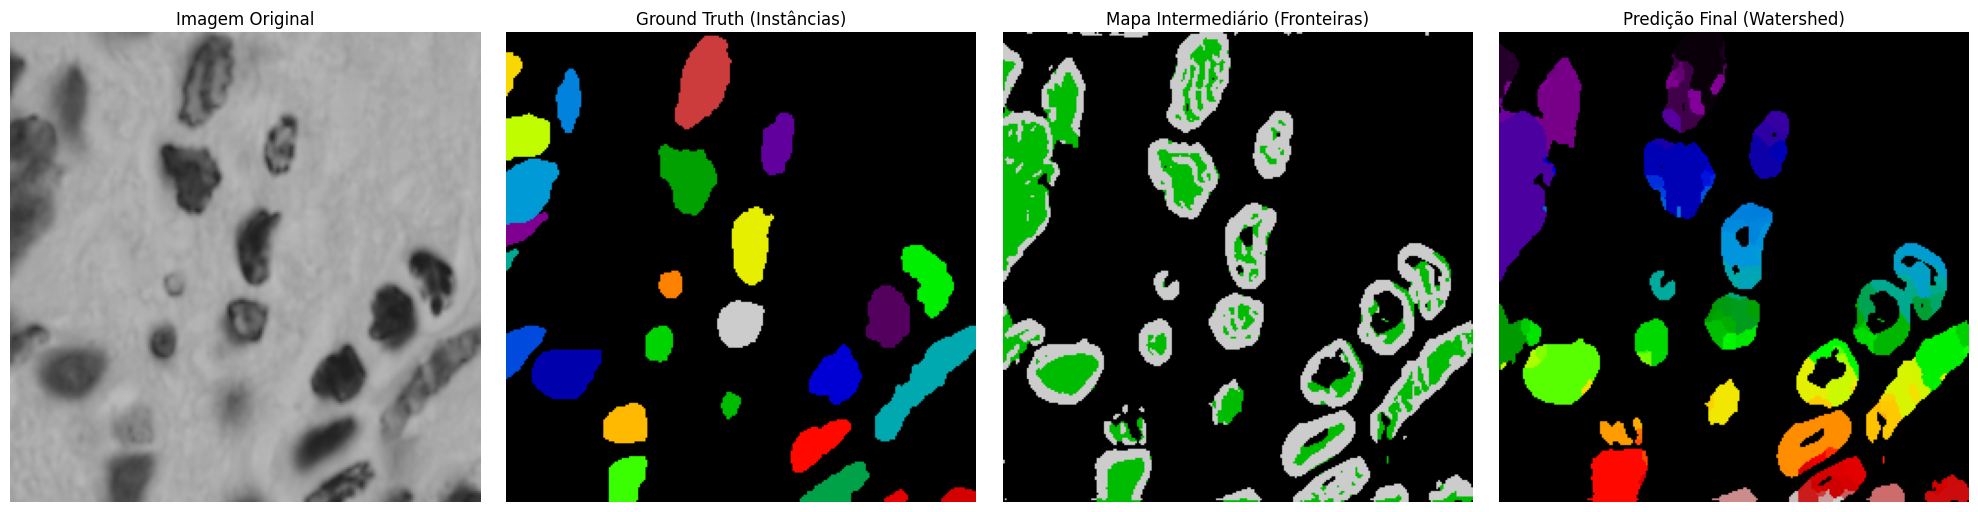

In [38]:
all_predicts = []

with torch.no_grad():
    for img, mask_original_batch in val_dataloader:
        img = img.to(device)
        mask_original_batch = mask_original_batch.to(device)

        mask_semantic_batch = border_mask(mask_original_batch)

        pred_logits = model(img)
        pred_classes = multiclass_decoder(pred_logits, dim=1).cpu().numpy().astype(int)

        mask_watershed_batch = watershed_decoder(torch.tensor(pred_classes))

        for b in range(img.shape[0]):

            img_plot = img[b].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_plot = (img_plot * std) + mean
            img_plot = np.clip(img_plot, 0, 1)

            # 2. Isola as máscaras da imagem atual (b)
            mask_orig = mask_original_batch[b, 0]
            mask_sem = mask_semantic_batch[b]
            pred_sem = pred_classes[b]
            mask_water = mask_watershed_batch[b, 0]

            # Componentes Conexas (Ingênuo) na saída da rede
            inst_matrix, num_obj = label(pred_sem)

            metrics = compute_instance_metrics_wrapper(mask_water, mask_orig)

            all_predicts.append([
                metrics.get('map', 0),
                img_plot,
                mask_orig.cpu().numpy(),
                mask_sem.cpu().numpy(),
                pred_sem,
                inst_matrix,
                mask_water.cpu().numpy()
            ])

# Identifica os 5 piores casos
all_predicts.sort(key=lambda x: x[0])
worst_predicts = all_predicts[:5]

# Bloco de plotagem atualizado para 4 imagens (1x4)
for i in range(5):
    print(f"\nAvaliação do Pior Caso #{i+1} | mAP: {worst_predicts[i][0]:.4f}")

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    axes = np.ravel(axes)

    axes[0].imshow(worst_predicts[i][1])
    axes[0].set(title="Imagem Original")
    axes[0].axis('off')

    axes[1].imshow(worst_predicts[i][2], cmap='nipy_spectral')
    axes[1].set(title="Ground Truth (Instâncias)")
    axes[1].axis('off')

    axes[2].imshow(worst_predicts[i][4], cmap='nipy_spectral')
    axes[2].set(title="Mapa Intermediário (Fronteiras)")
    axes[2].axis('off')

    axes[3].imshow(worst_predicts[i][6], cmap='nipy_spectral')
    axes[3].set(title="Predição Final (Watershed)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

Embora o cálculo anterior tenha mostrado que o campo receptivo é menor do que a maior célula presente na base de dados, pelas imagens acima podemos observar que este não é o único problema do nosso modelo, ele também falha em identificar células sobrepostas e células muito pequenas e próximas umas das outras. Com o campo receptivo curto, a rede não tem o contexto global para compreender o agrupamento, porém, se simplesmente expandirmos o campo de visão, a rede perde a acuidade espacial local (tentamos e deu bem errado) que é absolutamente indispensável para que o algoritmo Watershed consiga delinear as fronteiras finas entre as instâncias.

Para solucionar essa incapacidade de generalização de escalas, propomos a substituição do bottleneck tradicional da nossa U-Net por um módulo de Pyramid Scene Pooling (PSP). O PSP ataca o problema extraindo o contexto espacial em múltiplas escalas (através de poolings de diferentes dimensões) e concatenando esse resumo macroscópico ao mapa de características de alta resolução. Com essa intervenção, a rede não precisa escolher entre visão local ou global: ela ganha o contexto macroscópico necessário para interpretar corretamente os grandes aglomerados celulares, preservando simultaneamente a precisão pixel a pixel exigida para separar as fronteiras individuais de cada célula.

In [65]:
class PyramidPoolingModule(nn.Module):
    def __init__(self, in_channels, out_channels, pool_sizes=[1, 2, 3, 6]):
        super(PyramidPoolingModule, self).__init__()

        # O número de canais de cada nível da pirâmide (dividimos igualmente)
        out_channels_per_pool = in_channels // len(pool_sizes)

        # Criamos as camadas de pooling e redução de canais para cada escala
        self.stages = nn.ModuleList([
            nn.Sequential(
                nn.AdaptiveAvgPool2d(output_size=size),
                nn.Conv2d(in_channels, out_channels_per_pool, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels_per_pool),
                nn.ReLU(inplace=True)
            ) for size in pool_sizes
        ])

        # No final, concatenamos a entrada original (in_channels) com as 4 saídas da pirâmide
        # E usamos uma convolução para ajustar para o out_channels esperado pelo Decoder da U-Net
        concat_channels = in_channels + (out_channels_per_pool * len(pool_sizes))

        self.bottleneck = nn.Sequential(
            nn.Conv2d(concat_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        h, w = x.shape[2], x.shape[3]

        # A lista começa com o próprio mapa de características original (Alta Resolução)
        out = [x]

        # Passamos a imagem por cada nível da pirâmide (Contexto Global/Intermediário)
        for stage in self.stages:
            pooled = stage(x)
            # Esticamos o resumo de volta para o tamanho do mapa original
            upsampled = F.interpolate(pooled, size=(h, w), mode='bilinear', align_corners=False)
            out.append(upsampled)

        # Juntamos o mapa original com todos os resumos macroscópicos
        out = torch.cat(out, dim=1)

        return self.bottleneck(out)

class ModUNet(nn.Module):
    def __init__(self, in_channels, out_channels) -> None:
        super(ModUNet, self).__init__()
        # Encoder
        self.conv1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = PyramidPoolingModule(in_channels=128, out_channels=256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256,128,kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256,128)
        self.up2 = nn.ConvTranspose2d(128,64,kernel_size=2, stride=2)
        self.dec2 = DoubleConv(128,64)

        # Output
        self.final_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Passa pelo primeiro bloco e salva
        skip1 = self.conv1(x)
        x = self.pool1(skip1)
        skip2 = self.conv2(x)
        x = self.pool2(skip2)


        x = self.bottleneck(x)
        x = self.up1(x)
        x = torch.cat((skip2, x), dim=1)
        x = self.dec1(x)


        x = self.up2(x)
        x = torch.cat((skip1, x), dim=1)
        x = self.dec2(x)

        return self.final_conv(x)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_final = ModUNet(in_channels=3, out_channels=3).to(device)
optimizer = torch.optim.Adam(model_final.parameters(), lr=1e-4)

loss_fn = FocalLoss(gamma=1)
# Treinamento
metrics = train_model(
    model_final,
    loader_train=train_dataloader,
    loader_val=val_dataloader,
    optimizer=optimizer,
    epochs=50,
    loss=loss_fn,
    transform_mask=border_mask,
    decoder=multiclass_watershed_decoder,
    metric_function=compute_instance_metrics_wrapper,
    monitor_metric='map',
    stop_threshold=0.99,
    patience=10,
    best_model_path="models/best_model_parte_05.pth",
    dim=1
)

Epoch [1/50] | Val Loss: 0.3389 | Train Loss: 0.3788
Val MAP: 0.0675 | Val ABS_ERR: 82.9104
Epoch [5/50] | Val Loss: 0.1299 | Train Loss: 0.1433
Val MAP: 0.4008 | Val ABS_ERR: 11.7090
Epoch [10/50] | Val Loss: 0.0883 | Train Loss: 0.0982
Val MAP: 0.4451 | Val ABS_ERR: 9.7537
Early stopping: Sem melhoria por 10 epocas consecutivas.
Train time: 16.582661310831707 minutes



Avaliação do Pior Caso #1 | mAP: 0.0000


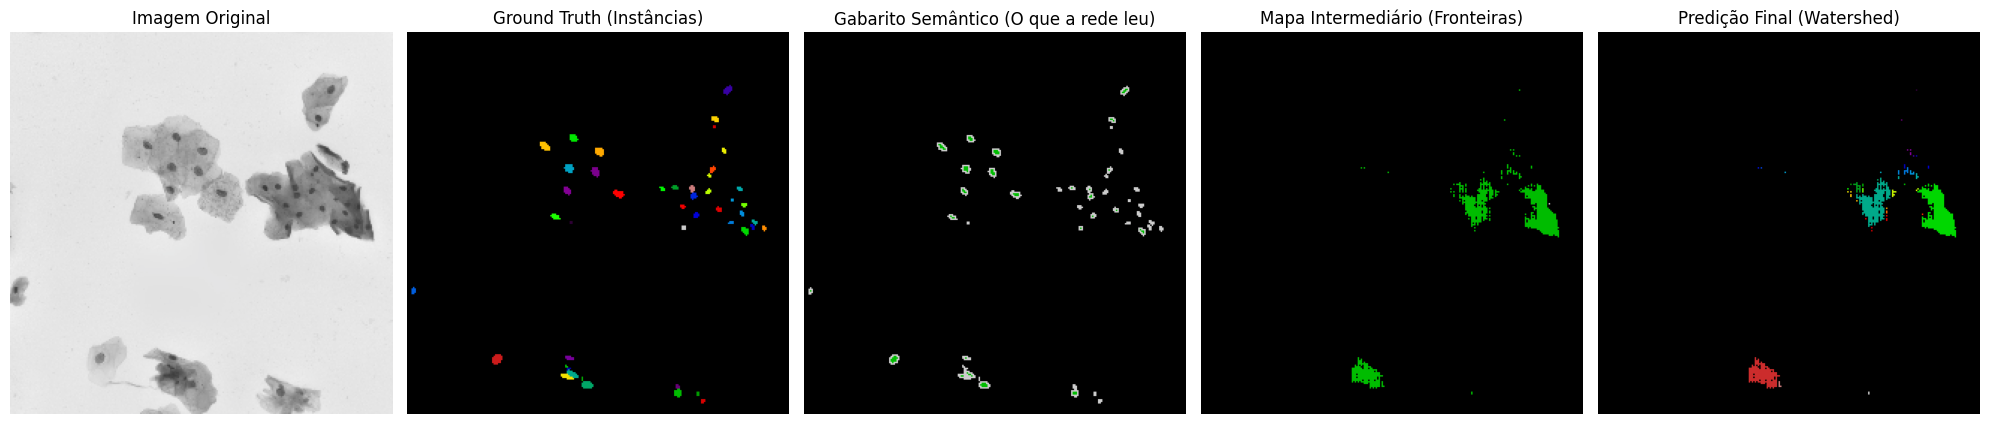


Avaliação do Pior Caso #2 | mAP: 0.0000


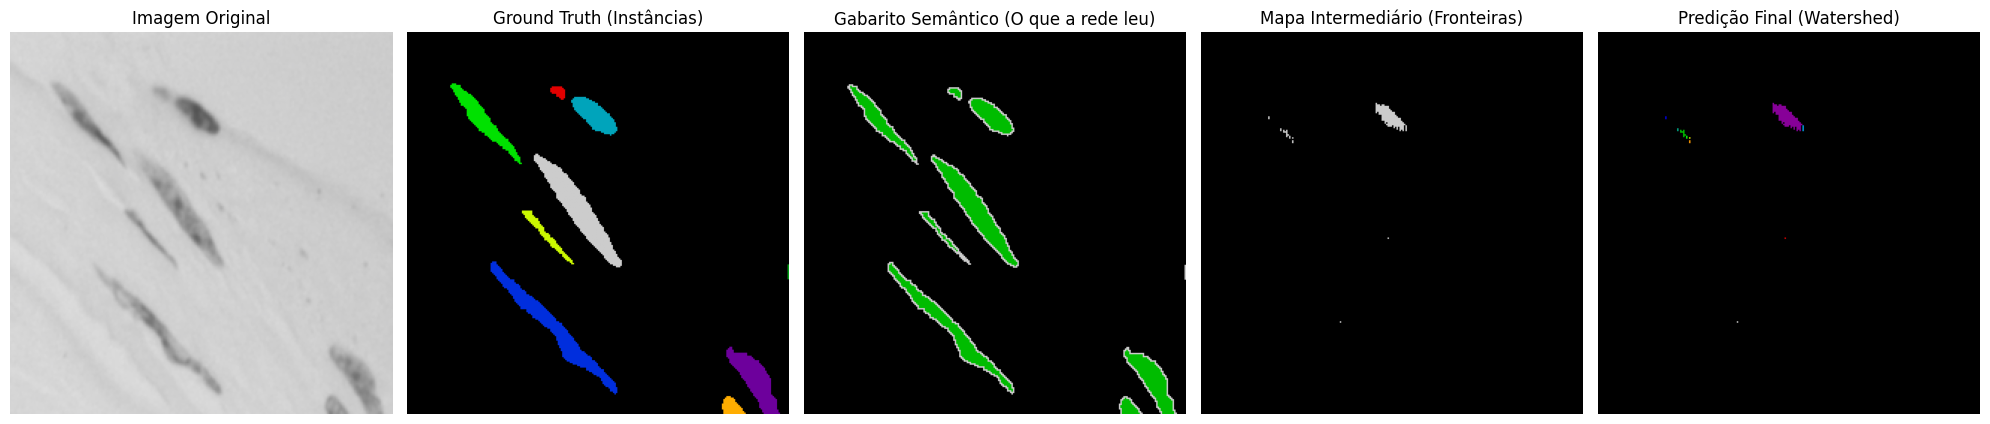


Avaliação do Pior Caso #3 | mAP: 0.0000


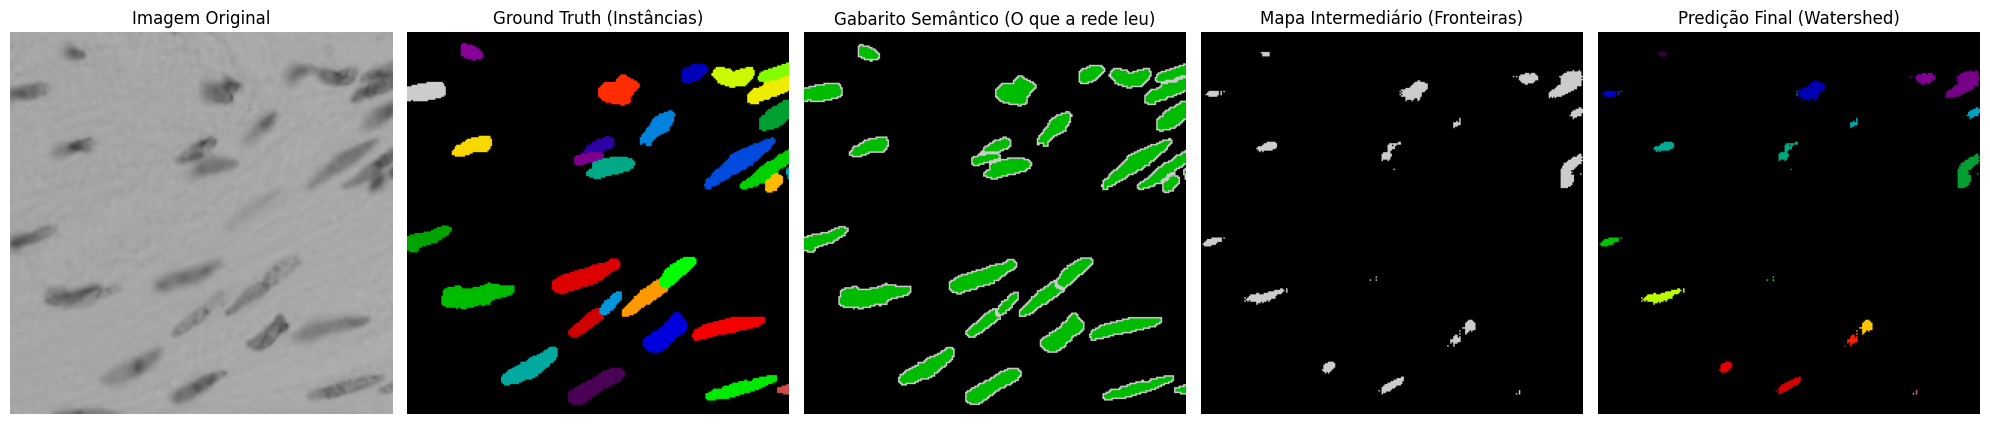


Avaliação do Pior Caso #4 | mAP: 0.0000


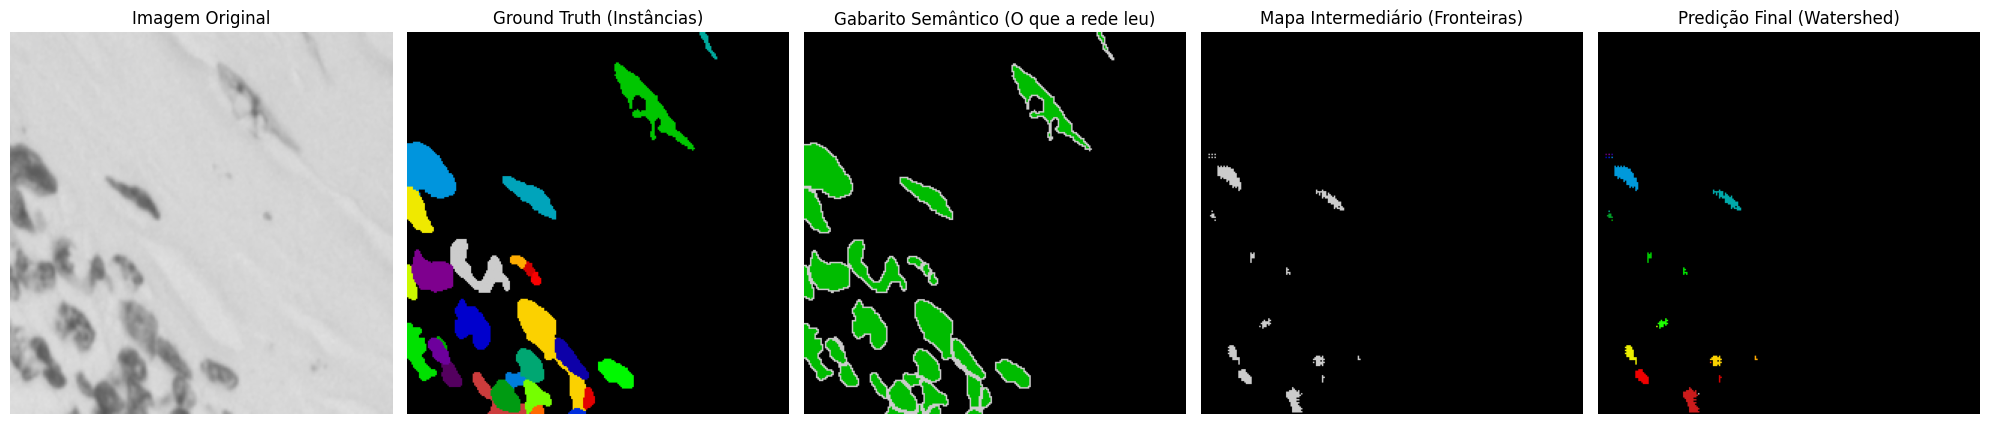


Avaliação do Pior Caso #5 | mAP: 0.0000


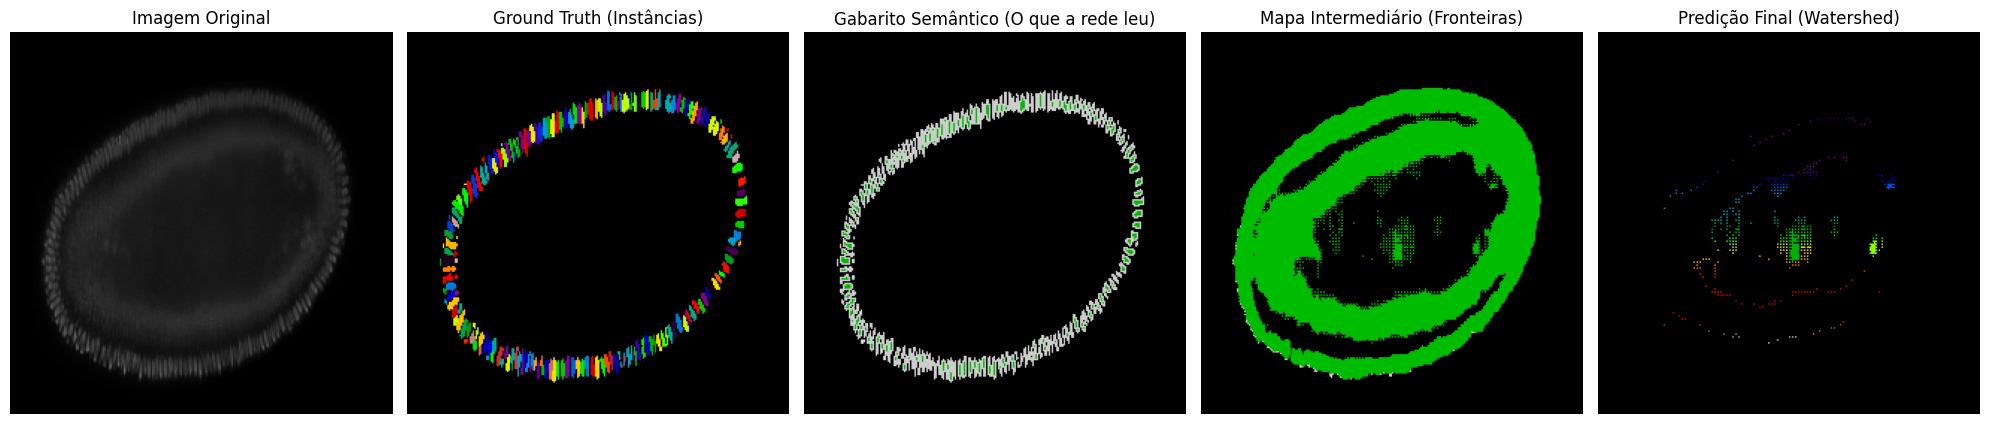

In [67]:
all_predicts = []

model.eval()
with torch.no_grad():
    for img, mask_original_batch in val_dataloader:
        img = img.to(device)
        mask_original_batch = mask_original_batch.to(device)

        mask_semantic_batch = border_mask(mask_original_batch)

        pred_logits = model(img)
        pred_classes = multiclass_decoder(pred_logits, dim=1).cpu().numpy().astype(int)

        mask_watershed_batch = watershed_decoder(torch.tensor(pred_classes))

        for b in range(img.shape[0]):

            img_plot = img[b].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img_plot = (img_plot * std) + mean
            img_plot = np.clip(img_plot, 0, 1)

            # Isola as máscaras da imagem atual (b)
            mask_orig = mask_original_batch[b, 0]
            mask_sem = mask_semantic_batch[b]
            pred_sem = pred_classes[b]
            mask_water = mask_watershed_batch[b, 0]

            # Componentes Conexas (Ingênuo) na saída da rede
            inst_matrix, num_obj = label(pred_sem)

            metrics = compute_instance_metrics_wrapper(mask_water, mask_orig)

            all_predicts.append([
                metrics.get('map', 0),
                img_plot,
                mask_orig.cpu().numpy(),
                mask_sem.cpu().numpy(),
                pred_sem,
                inst_matrix,
                mask_water.cpu().numpy()
            ])

# Identifica os 5 piores casos
all_predicts.sort(key=lambda x: x[0])
worst_predicts = all_predicts[:5]

# Bloco de plotagem para 5 imagens (1x5)
for i in range(5):
    print(f"\nAvaliação do Pior Caso #{i+1} | mAP: {worst_predicts[i][0]:.4f}")

    fig, axes = plt.subplots(1, 5, figsize=(20, 5))
    axes = np.ravel(axes)

    axes[0].imshow(worst_predicts[i][1])
    axes[0].set(title="Imagem Original")
    axes[0].axis('off')

    axes[1].imshow(worst_predicts[i][2], cmap='nipy_spectral')
    axes[1].set(title="Ground Truth (Instâncias)")
    axes[1].axis('off')

    axes[2].imshow(worst_predicts[i][3], cmap='nipy_spectral')
    axes[2].set(title="Gabarito Semântico (O que a rede leu)")
    axes[2].axis('off')

    axes[3].imshow(worst_predicts[i][4], cmap='nipy_spectral')
    axes[3].set(title="Mapa Intermediário (Fronteiras)")
    axes[3].axis('off')

    axes[4].imshow(worst_predicts[i][6], cmap='nipy_spectral')
    axes[4].set(title="Predição Final (Watershed)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()

A investigação sistemática das falhas do modelo base revelou que os erros persistentes não são limitações de campo receptivo (Bottleneck), mas sim barreiras fundamentais de representação de dados e domínio.

Viés de Domínio (Domain Shift): As falhas mais severas ocorrem em amostras de campo claro. Como a maioria do dataset é de microscopia fluorescente, as camadas iniciais da rede falham na extração de características (arestas e texturas) nesse domínio minoritário.

Limite da Representação de Borda: Em estruturas de densidade extrema, a exigência de regredir fronteiras de exato 1 pixel provou-se matematicamente instável. Intervenções para trazer contexto global, como o Pyramid Scene Pooling, ajudam a rede a identificar a massa celular, mas o sinal global sobrepõe a acuidade espacial fina necessária para o Watershed, resultando em fusão das instâncias.

# Parte 6

In [ ]:
def corrupt_transform(intensity):
    if intensity == 0:
        brightness_limit = 0.1
        contrast_limit   = 0.1
        std_range        = (0.05, 0.15)
        blur_limit       = (3, 5)
    elif intensity == 1:
        brightness_limit = 0.25
        contrast_limit   = 0.25
        std_range        = (0.15, 0.30)
        blur_limit       = (5, 9)
    else:
        brightness_limit = 0.5
        contrast_limit   = 0.5
        std_range        = (0.30, 0.5)
        blur_limit       = (9, 15)
        
    return A.Compose([
        # Forca image e mask para 256x256
        A.Resize(height=256, width=256),
        
        # Brilho e Contraste
        A.RandomBrightnessContrast(
            brightness_limit=brightness_limit, # Varia o brilho em +/- 20%
            contrast_limit=contrast_limit,   # Varia o contraste em +/- 20%
            p=1.0
        ),

        # Ruido (Simula artefatos de sensores de microscopio ISO alto)
        A.GaussNoise(
            std_range=std_range, # Intensidade do granulado
            p=1.0
        ),

        # Blur (Simula perda de foco da lente ou movimento)
        A.OneOf([
            A.GaussianBlur(blur_limit=blur_limit, p=1.0), # Desfoque suave gaussiano
            A.MedianBlur(blur_limit=blur_limit, p=1.0),        # Desfoque que borra mantendo bordas pesadas
            A.MotionBlur(blur_limit=blur_limit, p=1.0),        # Simula a lamina escorregando
        ], p=1.0), 
        
        # Padroniza o espectro de cores como cinza
        A.ToGray(p=1.0),

        # Normaliza os pixels para o padrao ImageNet
        A.Normalize(mean=MEAN, std=STD),

        # Converte os arrays Numpy para Tensores do PyTorch e ajusta as dimensoes ((H, W, C) ==> (C, H, W))
        ToTensorV2()
    ])

In [ ]:
batch_size = 16

intensity_datasets = {}

for intensity in [0, 1, 2]:
    corrupted_dataset = BBBC038Dataset("data/stage1_train", corrupt_transform(intensity))
    # dataloader = DataLoader(dataset, batch_size=batch_size)
    corrupted_train_dataset, corrupted_val_dataset = torch.utils.data.dataset.random_split(corrupted_dataset, [0.8, 0.2])
    corrupted_train_dataloader = DataLoader(corrupted_train_dataset, batch_size=batch_size, shuffle=True)
    corrupted_val_dataloader = DataLoader(corrupted_val_dataset, batch_size=batch_size, shuffle=True)
    
    intensity_datasets[intensity] = [corrupted_train_dataloader, corrupted_val_dataloader]

In [ ]:
with torch.no_grad():
    true_positives  = [[], [], [], []]
    false_positives = [[], [], [], []]
    false_negatives = [[], [], [], []]
    
    for intensity, each_val_dataloader in enumerate([val_dataloader, *[v[1] for v in intensity_datasets.values()]]):
        for i, (img, mask) in enumerate(each_val_dataloader):
            img = img.to(device)
            mask = mask.to(device)
            
            pred = model(img)
            pred = multiclass_decoder(pred, dim=1).int()
            
            # Watershed
            mask_watershed = watershed_decoder(pred)
            pred           = pred.unsqueeze(1).cpu().numpy().astype(int)
            
            for b in range(mask.shape[0]):
                _, iou_matrix = compute_intersection(mask_true=mask[b].cpu(), mask_pred=mask_watershed[b][0])
                tp, fp, fn, mean_average_precision, abs_count_error = compute_metrics(iou_matrix, np.arange(0.5, 1, 0.05))
                true_positives[intensity].append(tp)
                false_positives[intensity].append(fp)
                false_negatives[intensity].append(fn)
                
        # Agrega as metricas finais
        tp = np.sum(true_positives[intensity], axis=0)
        fp = np.sum(false_positives[intensity], axis=0)
        fn = np.sum(false_negatives[intensity], axis=0)
        
        mean_average_precision = tp / (tp + fp + fn)
        plt.plot(np.arange(0.5, 1, 0.05), mean_average_precision, label=f"Intensidade {intensity}" if intensity else "Baseline - Sem corrupção")
        
    plt.xlabel("Limiar de IoU")
    plt.ylabel("mAP")
    plt.title("Curva de degradação do mAP por intensidade de corrupção")      
    plt.legend()